# Bayesian Optimization

Imagine you need to find the best settings for a complex system – perhaps tuning the hyperparameters of a deep learning model, optimizing the design of an experiment, or finding the ideal parameters for a simulation. Often, evaluating the system with a given set of parameters (i.e., running the experiment or training the model) is expensive, time-consuming, or resource-intensive. How can you find the optimal settings without performing an exhaustive search?

This is where **Bayesian Optimization (BO)** comes in. It's a powerful, sequential strategy designed specifically for the **global optimization of black-box functions**. These are functions where:

1.  We don't know the underlying mathematical form (it's a "black box").
2.  Evaluating the function (getting an output `y` for an input `x`) is costly.
3.  We often cannot compute derivatives (gradients).
4.  The observations might be noisy (the output `y` can vary even for the same input `x`).

BO tackles this challenge by intelligently choosing the next point to evaluate, aiming to find the optimum (maximum or minimum) in as few evaluations as possible.

### Core Components

Bayesian Optimization cleverly balances exploring unknown parts of the search space and exploiting areas known to yield good results. It does this using two main components:

1.  **A Probabilistic Surrogate Model:** This model approximates the unknown objective function based on the points observed so far. It also provides uncertainty estimates about the function's behavior in unexplored regions. Gaussian Processes (GPs) are the most common choice for this surrogate model due to their flexibility and inherent uncertainty quantification.
2.  **An Acquisition Function:** This function uses the surrogate model's predictions (mean and uncertainty) to determine the 'utility' of evaluating any given point in the search space. It guides the search by suggesting the point that is most likely to lead to an improvement, considering both the predicted performance and the uncertainty. Examples include Expected Improvement (EI) and Upper Confidence Bound (UCB).

### The Iterative Process

The BO algorithm works iteratively:

1.  **Observe:** Evaluate the black-box function at one or more points chosen by the acquisition function.
2.  **Update:** Update the surrogate model (e.g., the Gaussian Process) using all the data collected so far (inputs and their observed outputs).
3.  **Select:** Optimize the acquisition function (which is cheap to evaluate) over the search space to find the most promising point(s) to evaluate next.
4.  **Repeat:** Continue this cycle until a stopping criterion is met (e.g., budget of function evaluations exhausted, desired performance level reached).


### Recommended reading:
1. [A Tutorial on Bayesian Optimization](https://arxiv.org/pdf/1807.02811)
1. [BayesOpt docs](https://bayesian-optimization.github.io/BayesianOptimization/2.0.3/)
1. [Exploring Bayesian Optimization](https://distill.pub/2020/bayesian-optimization/)
1. [Acquisition functions in Bayesian Optimization](https://ekamperi.github.io/machine%20learning/2021/06/11/acquisition-functions.html)
1. [A Visual Exploration of Gaussian Processes](https://distill.pub/2019/visual-exploration-gaussian-processes/)
1. [Practical Bayesian Optimization of Machine Learning Algorithms](https://arxiv.org/abs/1206.2944)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition

# Set random seed for reproducibility
np.random.seed(42)

### Define and visualize the target function
First, we'll create a synthetic objective function to optimize. This specific function has three peaks (at x=0, x≈2 and x≈6) and is a toy example.

$$f(x) = e^{-(x - 2)^2} + e^{-\frac{(x - 6)^2}{10}} + \frac{1}{x^2 + 1}$$

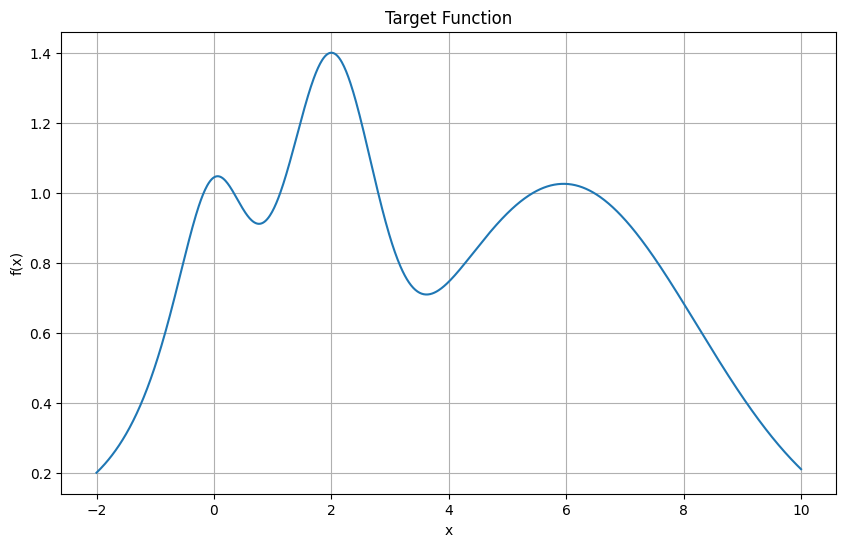

In [2]:
def target_function(x):
    """Our example target function to be optimized"""
    return np.exp(-((x - 2) ** 2)) + np.exp(-((x - 6) ** 2) / 10) + 1 / (x**2 + 1)


x = np.linspace(-2, 10, 1000)
y = target_function(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.grid(True)
plt.title("Target Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

### Define visualization functions
These helper functions will visualize the Gaussian Process model
and acquisition function at each step of the optimization process.
They help us understand how the model evolves as more observations are made.

In [3]:
def posterior(optimizer, grid):
    """Get posterior mean and standard deviation from GP model"""
    mu, sigma = optimizer._gp.predict(grid, return_std=True)
    return mu, sigma

def plot_gp(optimizer, x, y, save_path=None):
    """Plot the Gaussian Process model, observations, and acquisition function"""
    fig = plt.figure(figsize=(16, 10))
    steps = len(optimizer.space)
    fig.suptitle(
        f"Gaussian Process and Utility Function After {steps} Steps",
        fontsize=30,
    )

    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    axis = plt.subplot(gs[0])
    acq = plt.subplot(gs[1])

    x_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])

    optimizer.acquisition_function._fit_gp(optimizer._gp, optimizer._space)
    mu, sigma = posterior(optimizer, x)

    axis.plot(x, y, linewidth=3, label="Target")
    axis.plot(
        x_obs.flatten(), y_obs, "D", markersize=8, label="Observations", color="r"
    )
    axis.plot(x, mu, "--", color="k", label="Prediction")

    axis.fill(
        np.concatenate([x, x[::-1]]),
        np.concatenate([mu - 1.9600 * sigma, (mu + 1.9600 * sigma)[::-1]]),
        alpha=0.6,
        fc="c",
        ec="None",
        label="95% confidence interval",
    )

    axis.set_xlim((-2, 10))
    axis.set_ylim((None, None))
    axis.set_ylabel("f(x)", fontdict={"size": 20})
    axis.set_xlabel("x", fontdict={"size": 20})

    utility_function = optimizer.acquisition_function
    utility = -1 * utility_function._get_acq(gp=optimizer._gp)(x)
    x_flat = x.flatten()

    acq.plot(x_flat, utility, label="Utility Function", color="purple")
    acq.plot(
        x_flat[np.argmax(utility)],
        np.max(utility),
        "*",
        markersize=15,
        label="Next Best Guess",
        markerfacecolor="gold",
        markeredgecolor="k",
        markeredgewidth=1,
    )
    acq.set_xlim((-2, 10))
    acq.set_ylabel("Utility", fontdict={"size": 20})
    acq.set_xlabel("x", fontdict={"size": 20})

    axis.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)
    acq.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

    return fig

We'll now see Bayesian Optimization in action, step by step.
At each step, observe:
1. How the GP model (dashed line) is updated
2. How the confidence interval (light blue area) changes
3. How the acquisition function (purple line) guides the next sample
4. Where the next sample point (gold star) is placed

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |

Step 0: Initial random points


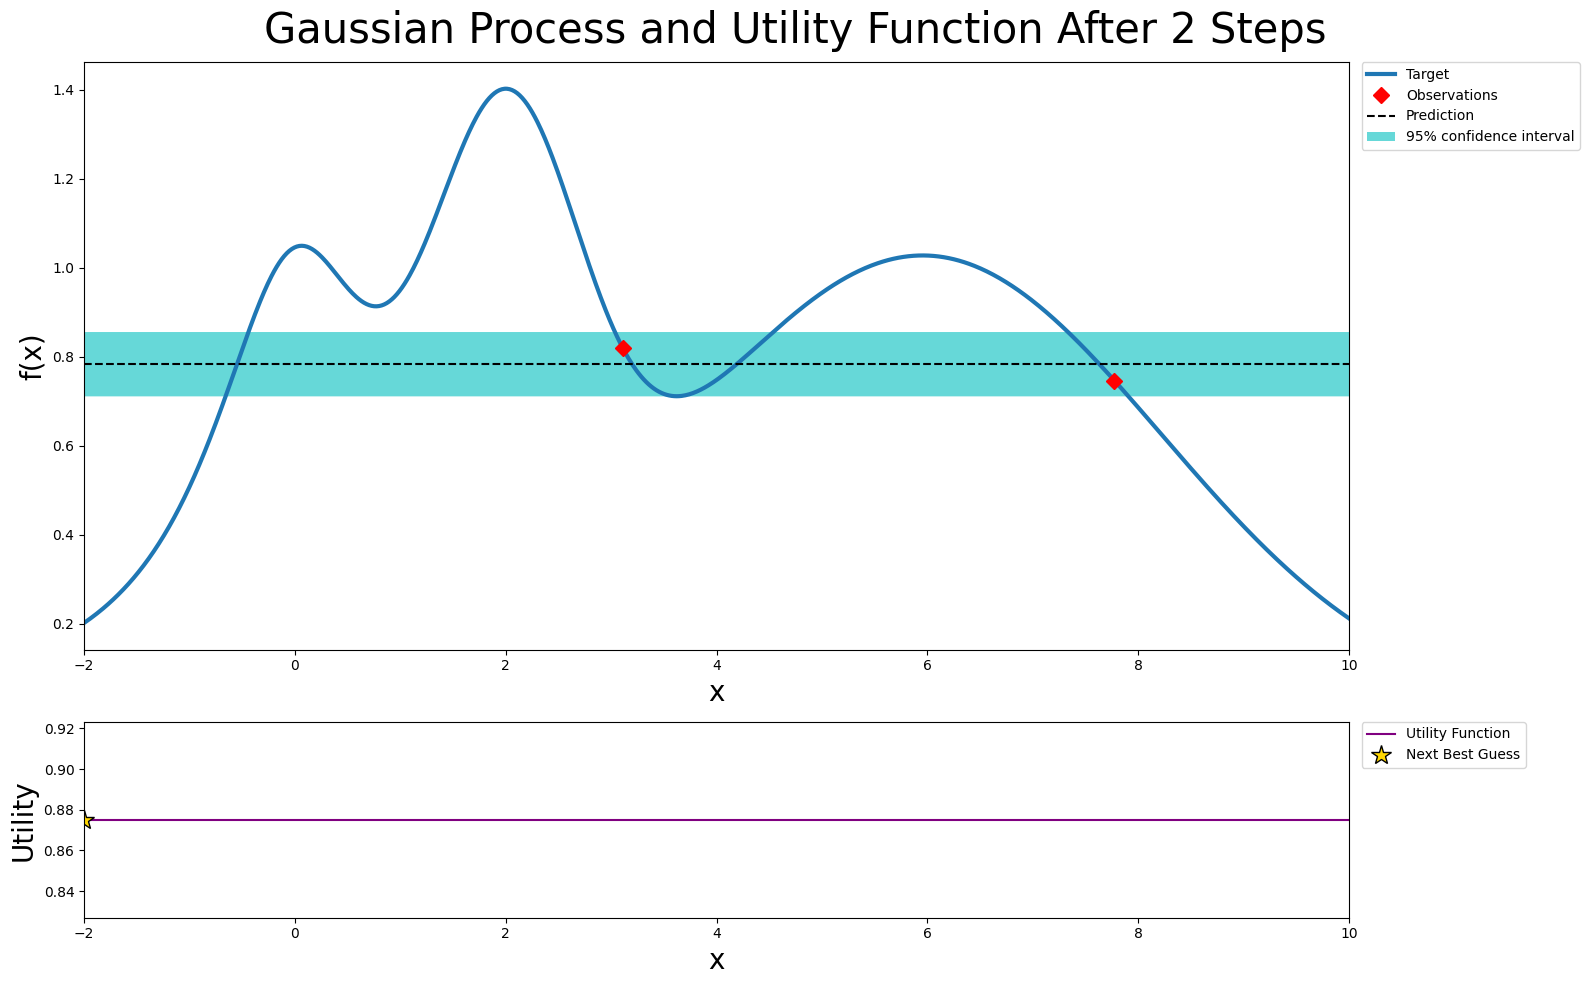

|   iter    |  target   |     x     |
-------------------------------------
| 3         | 0.8190422 | 3.1102721 |

Step 1: Added a new observation


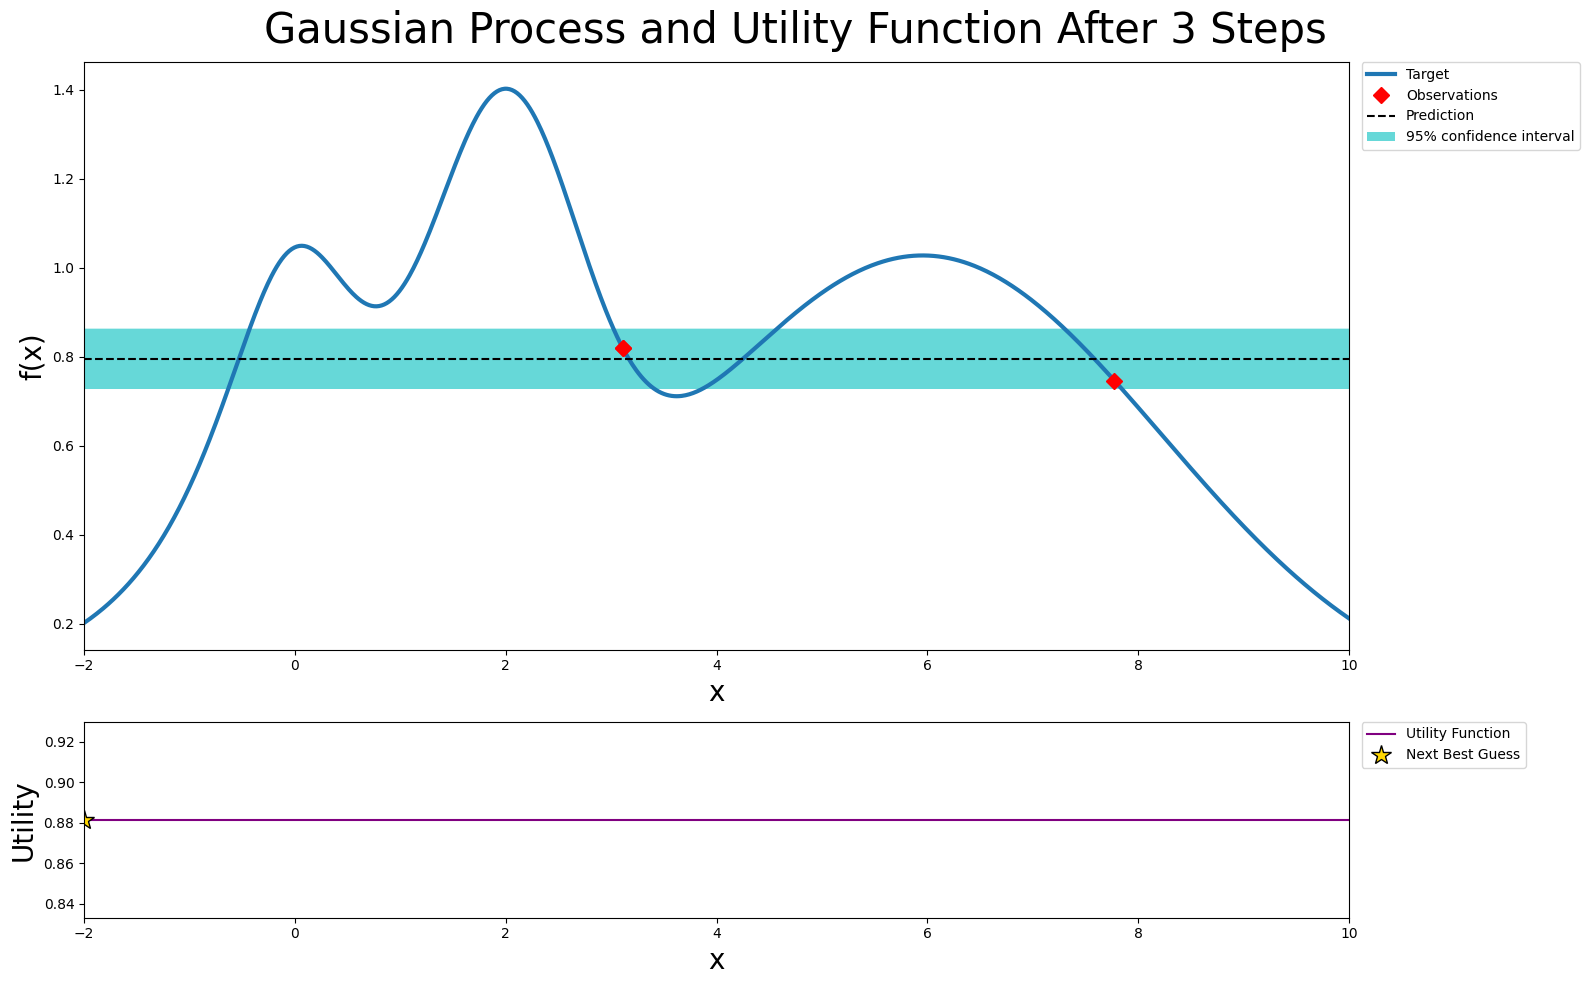

|   iter    |  target   |     x     |
-------------------------------------
| 4         | 0.8943137 | 2.9649330 |

Step 2: Added a new observation


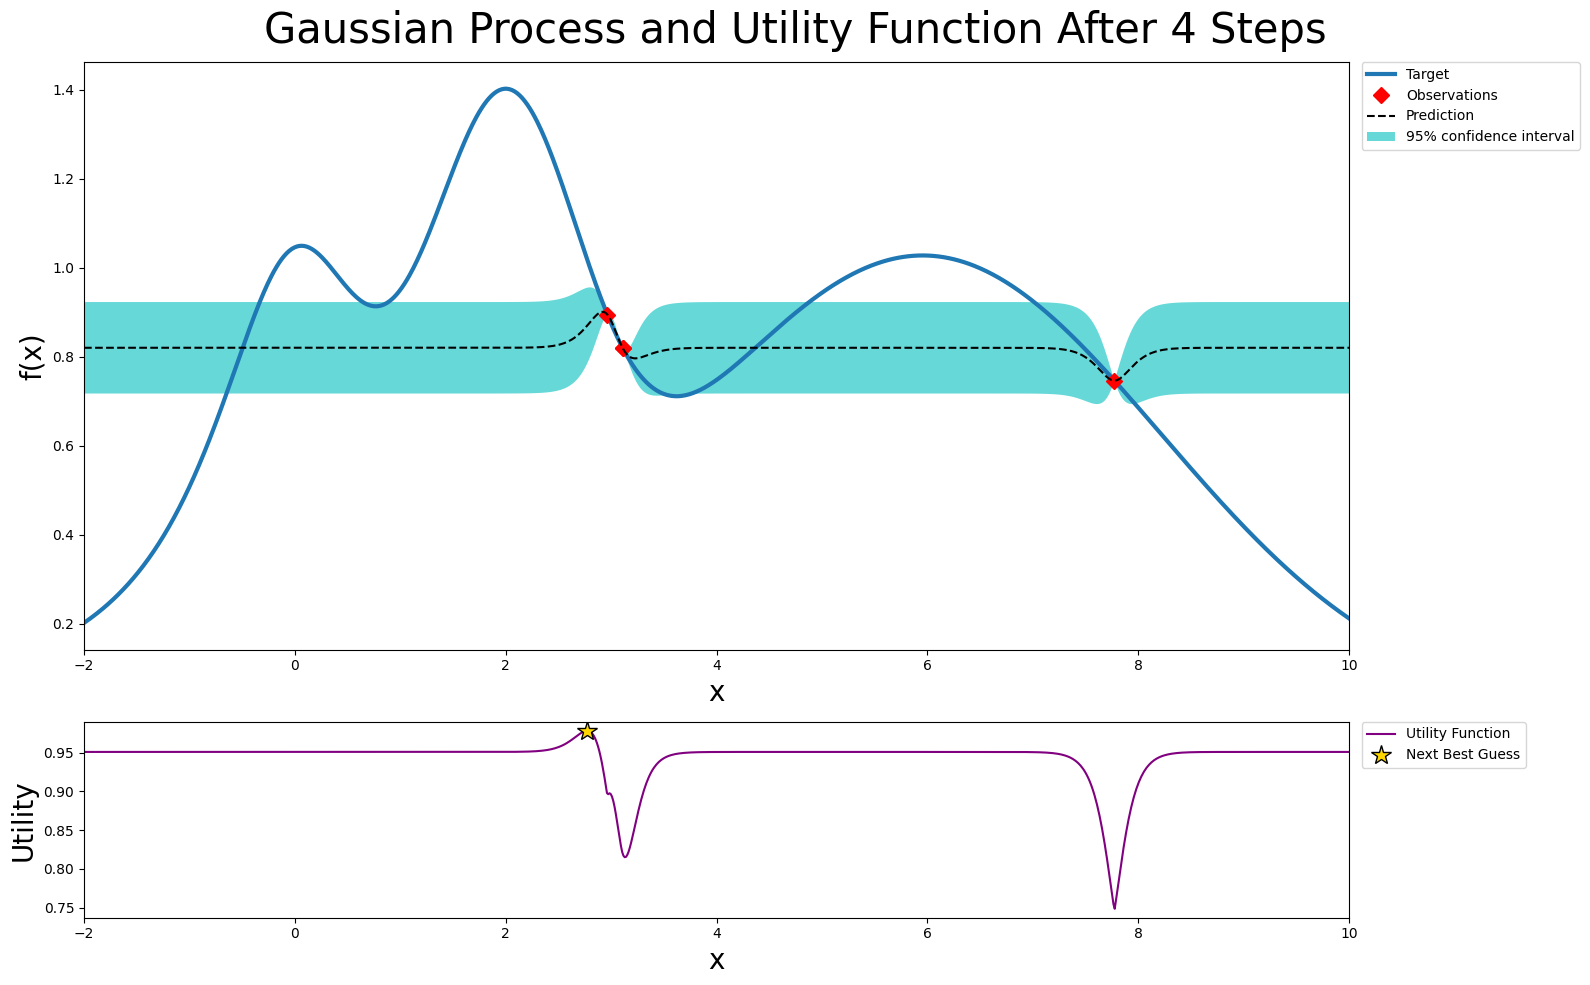

|   iter    |  target   |     x     |
-------------------------------------
| 5         | 1.0188851 | 2.7720553 |

Step 3: Added a new observation


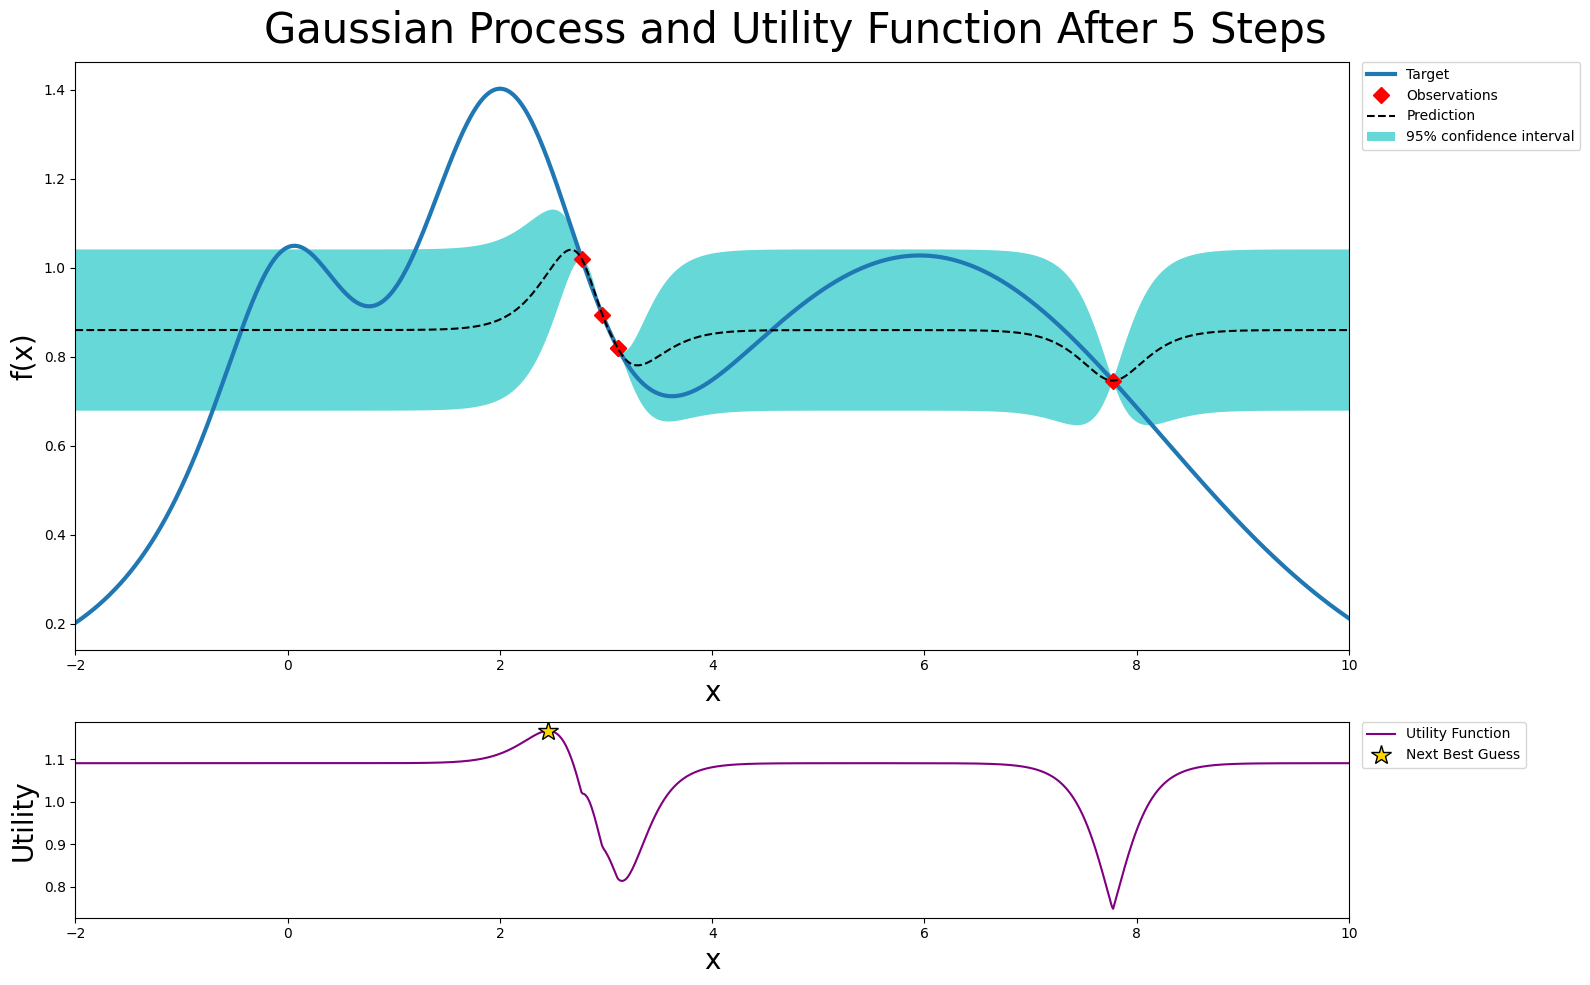

|   iter    |  target   |     x     |
-------------------------------------
| 6         | 1.2389517 | 2.4564829 |

Step 4: Added a new observation


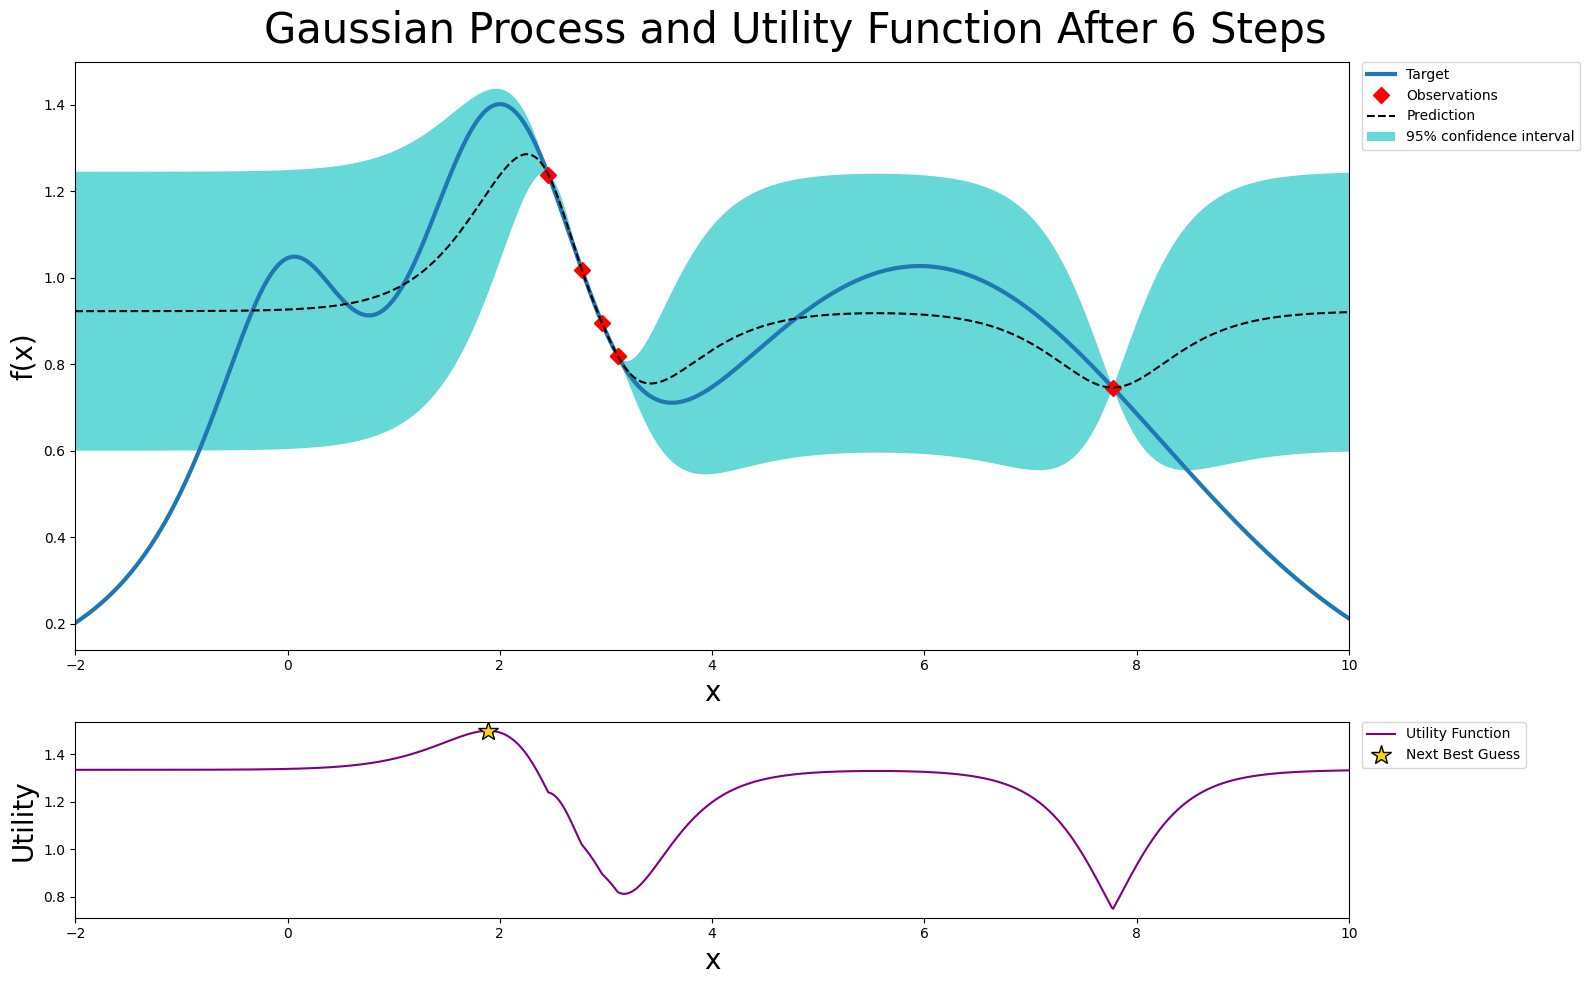

|   iter    |  target   |     x     |
-------------------------------------
| 7         | 1.3911164 | 1.8887342 |

Step 5: Added a new observation


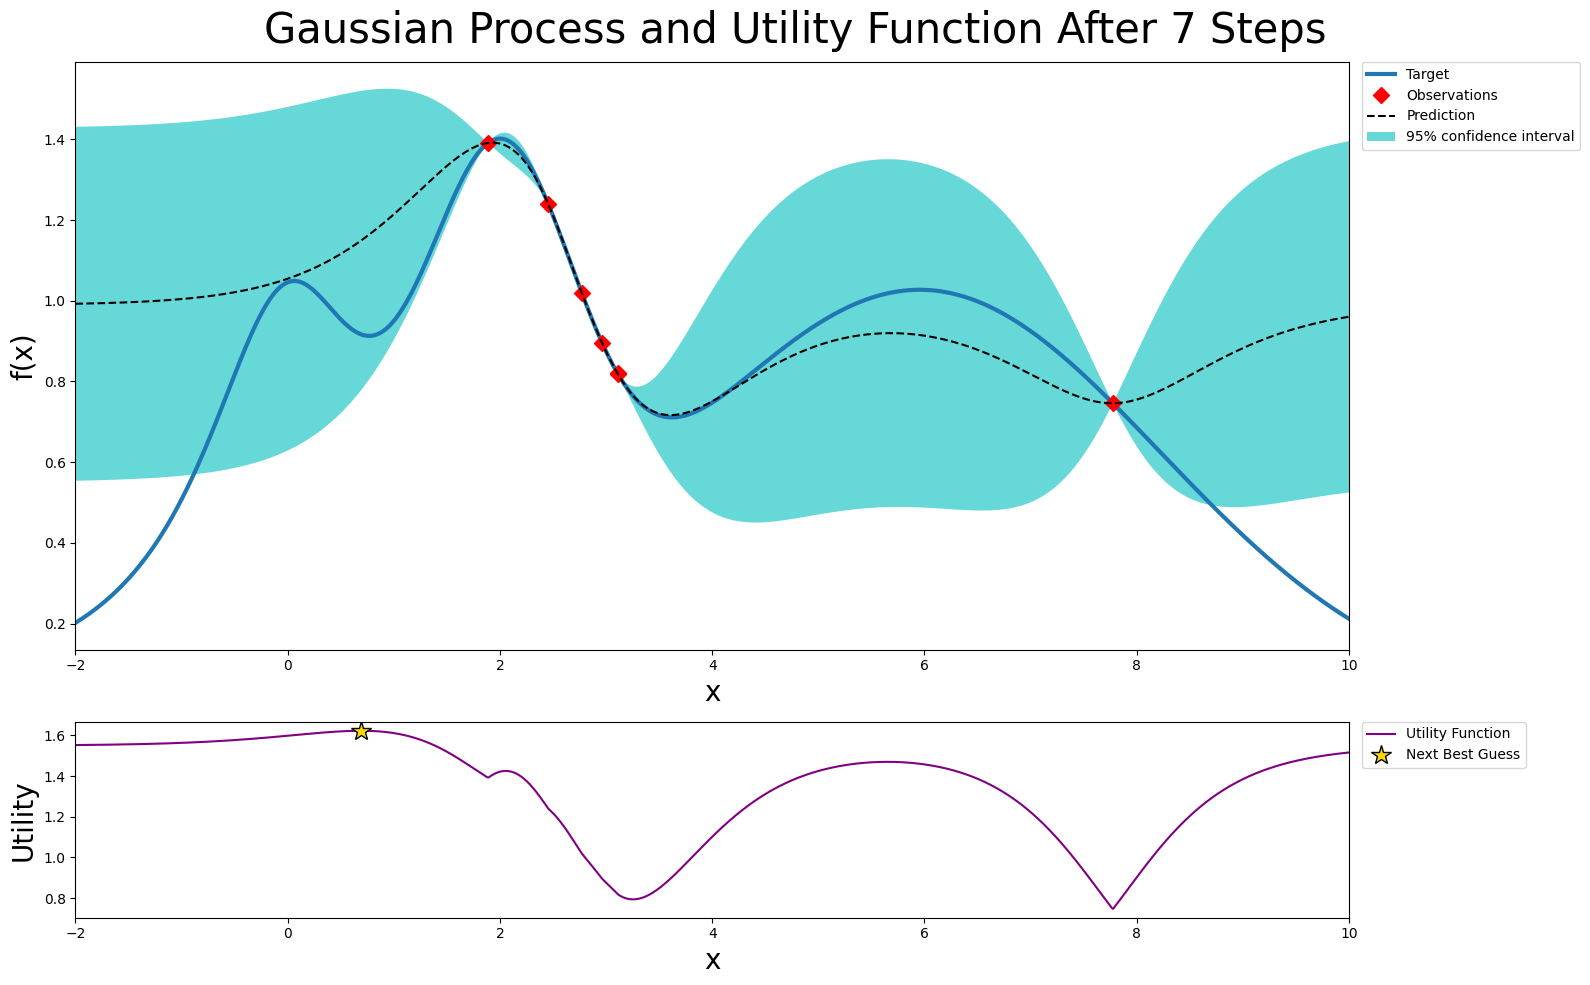


Final result:
Best target value found: 1.3911
Best input value found: x = 1.8887


In [4]:
acquisition_function = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=acquisition_function,
    random_state=27,
)

# Prepare data for visualization
x = np.linspace(-2, 10, 1000).reshape(-1, 1)
y = target_function(x)

# Initialize with 2 random points
optimizer.maximize(init_points=2, n_iter=0)
print("\nStep 0: Initial random points")
plot_gp(optimizer, x, y)

for i in range(1, 6):
    optimizer.maximize(init_points=0, n_iter=1)
    print(f"\nStep {i}: Added a new observation")
    plot_gp(optimizer, x, y)

print("\nFinal result:")
print(f"Best target value found: {optimizer.max['target']:.4f}")
print(f"Best input value found: x = {optimizer.max['params']['x']:.4f}")

Acquisition functions guide the sampling process by balancing:
- Exploitation: Sampling where the model predicts high values
- Exploration: Sampling where the model is uncertain

We'll compare three different acquisition functions:
1. Upper Confidence Bound (UCB): Balances exploration and exploitation
2. Probability of Improvement (PI): More exploitative
3. Greedy: Purely exploitative (custom implementation)

In [5]:
class GreedyAcquisition(acquisition.AcquisitionFunction):
    """Purely exploitative acquisition function (only considers mean)"""

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return mean  # disregard std

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856630 | -0.211813 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351170 | 4.9507496 |

UCB Acquisition Function Results:


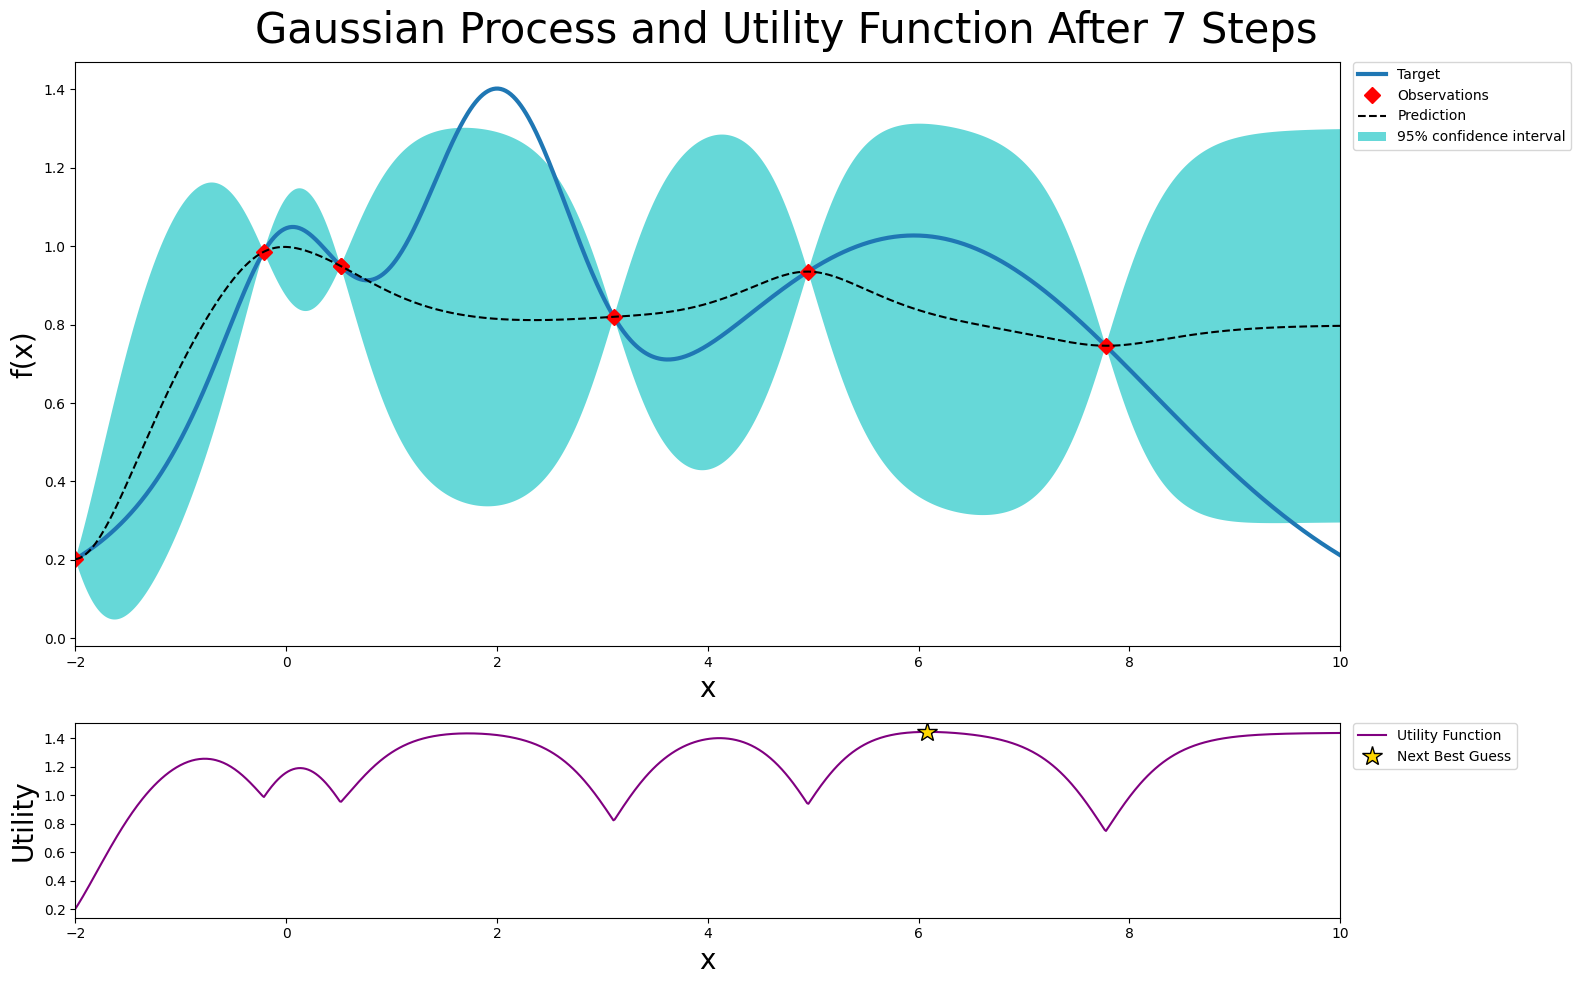

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495500 | 0.5165817 |
| 5         | 0.9526277 | 0.5049405 |
| 6         | 0.9553089 | 0.4950240 |
| 7         | 0.9594185 | 0.4801647 |

Probability of Improvement Acquisition Function Results:


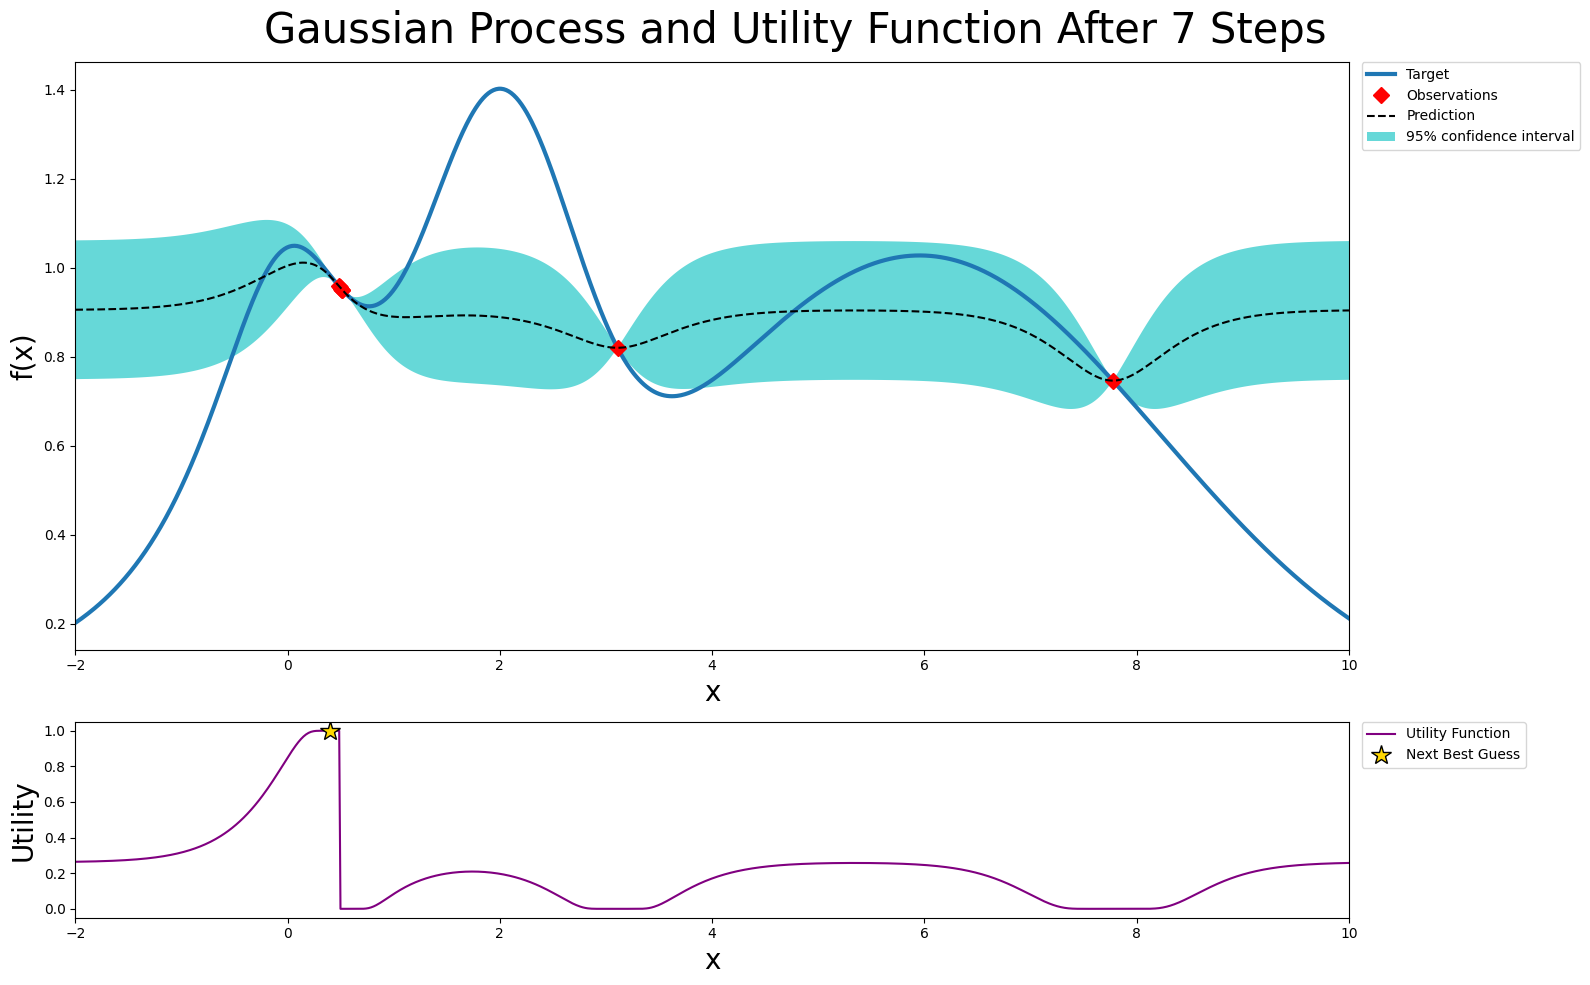

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495499 | 0.5165820 |
| 5         | 0.9495499 | 0.5165820 |
| 6         | 0.9495499 | 0.5165820 |
| 7         | 0.9495499 | 0.5165820 |

Greedy (Purely Exploitative) Acquisition Function Results:


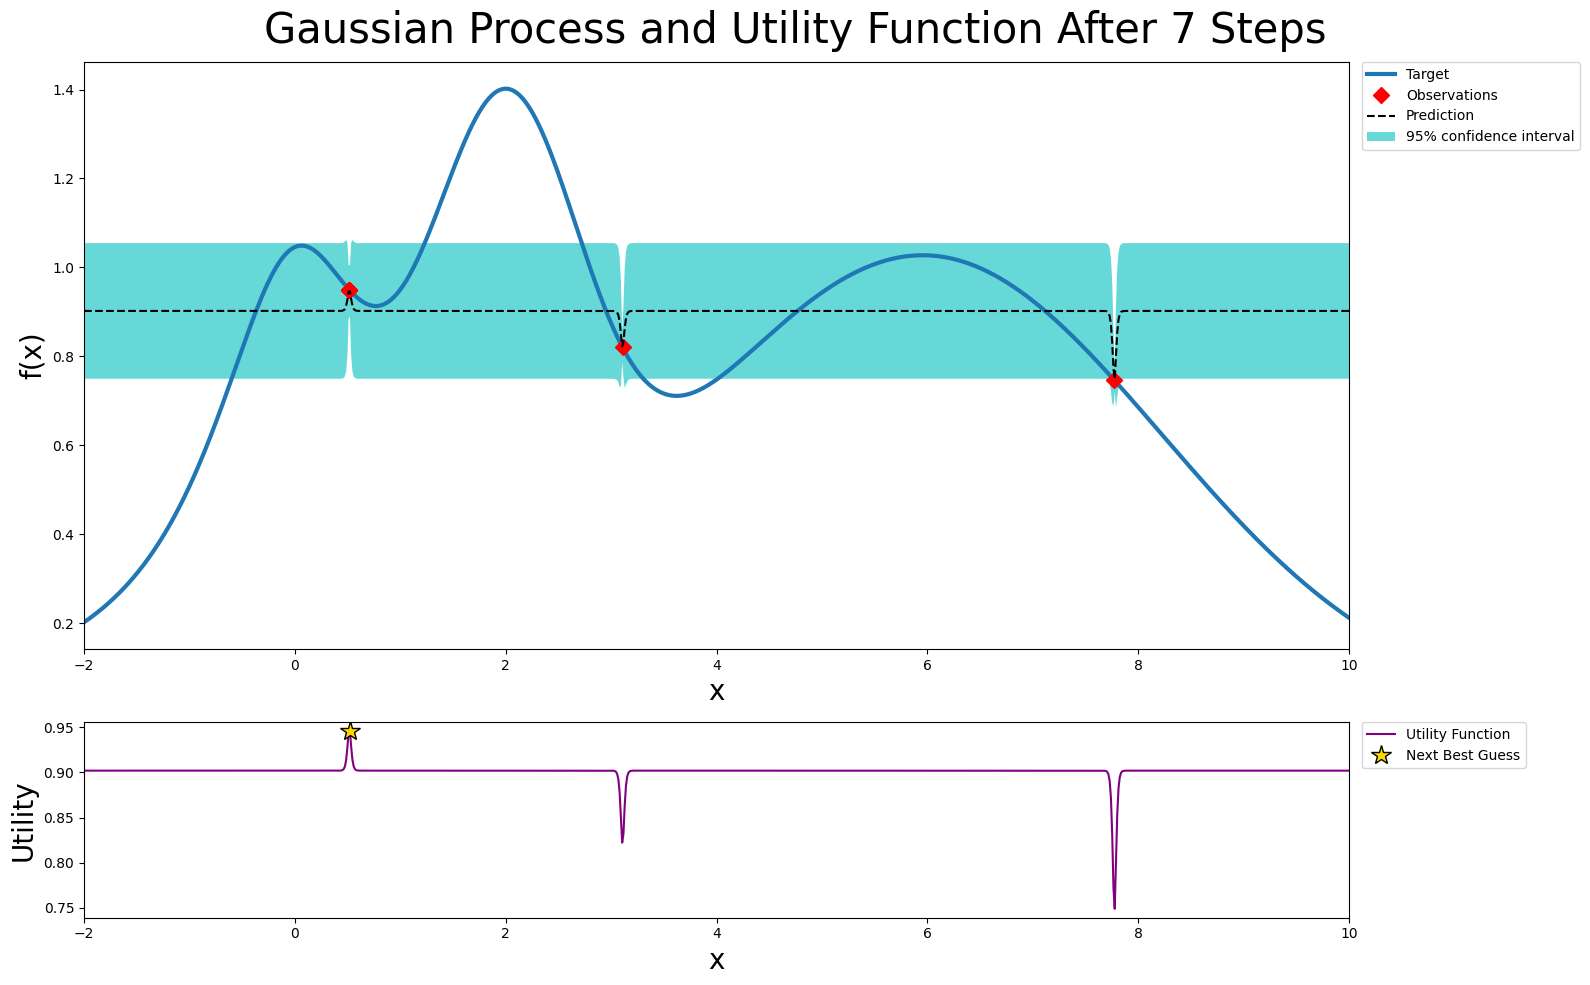


Summary of results:
UCB best value: 0.9857 at x = -0.2118
PI best value: 0.9594 at x = 0.4802
Greedy best value: 0.9495 at x = 0.5166


In [6]:
ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Acquisition Function Results:")
plot_gp(optimizer_ucb, x, y)

# Run with PI
pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nProbability of Improvement Acquisition Function Results:")
plot_gp(optimizer_pi, x, y)

# Run with Greedy
greedy = GreedyAcquisition()
optimizer_greedy = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=greedy,
    random_state=27,
)

optimizer_greedy.maximize(init_points=2, n_iter=5)
print("\nGreedy (Purely Exploitative) Acquisition Function Results:")
plot_gp(optimizer_greedy, x, y)

# Summary
print("\nSummary of results:")
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)
print(
    f"Greedy best value: {optimizer_greedy.max['target']:.4f} at x = {optimizer_greedy.max['params']['x']:.4f}"
)

Comment these results. Write your observations in a Markdown cell.

<div class="alert alert-block alert-info">
<b>Comment:</b> Different acquisition functions influence the selection of sampling points. Those that prioritize reducing uncertainty ensure better coverage of the space and provide better knowledge of the function, but generally at the cost of redundant sampling. On the other hand, exploitative functions leverage existing knowledge and sample points that are already known to be decent. The acquisition function should be chosen according to the specific problem - depending on the sampling cost (if it is high, I assume it is better to opt for a more exploitative variant) or our assumptions regarding the function.
</div>

Exercise 1: UCB
---------------

The parameter kappa in the UCB acquisition function controls the trade-off between:
- Exploration (high kappa): More emphasis on the uncertainty
- Exploitation (low kappa): More emphasis on the predicted mean

Compare results for UCB using 3 different values:
1. kappa = 0.1 (Mostly exploitation)
2. kappa = 2.5 (Balanced)
3. kappa = 5.0 (Mostly exploration)

Review this [blog post](https://ekamperi.github.io/machine%20learning/2021/06/11/acquisition-functions.html) and explain the underlying concept of UCB in a Markdown cell.

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495496 | 0.5165830 |
| 5         | 0.9561417 | 0.4919817 |
| 6         | 1.0125033 | 0.2974808 |
| 7         | 1.0463086 | 0.0066688 |

UCB with kappa=0.1 Results:


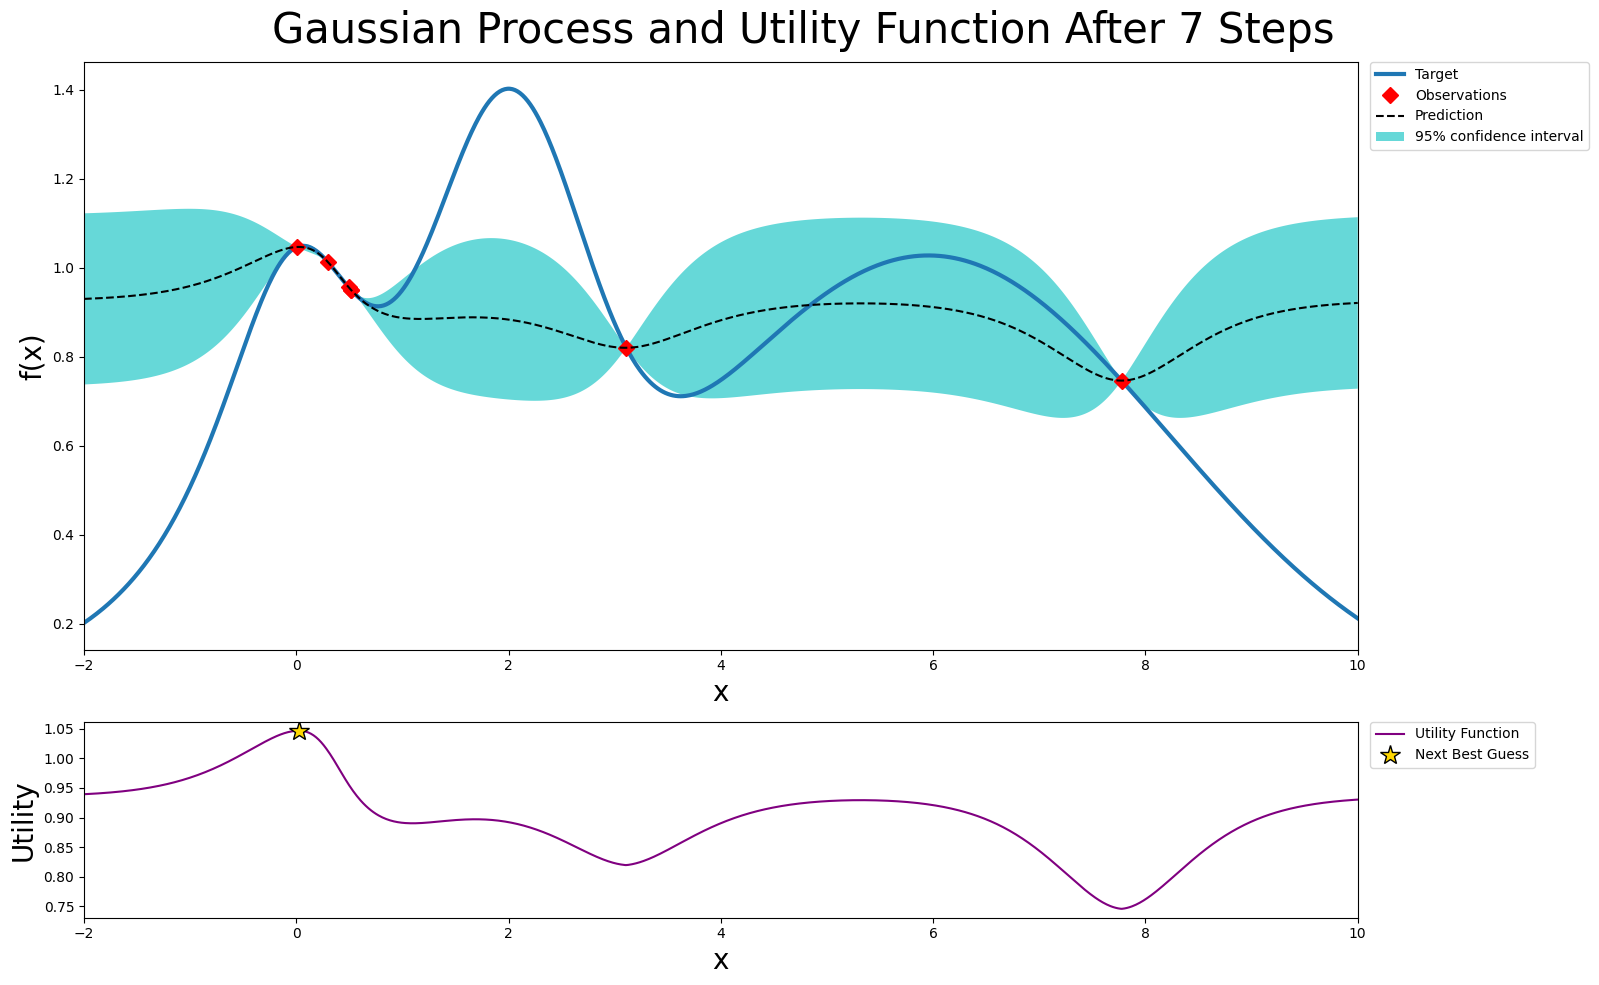

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856630 | -0.211813 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351170 | 4.9507496 |

UCB with kappa=2.5 Results:


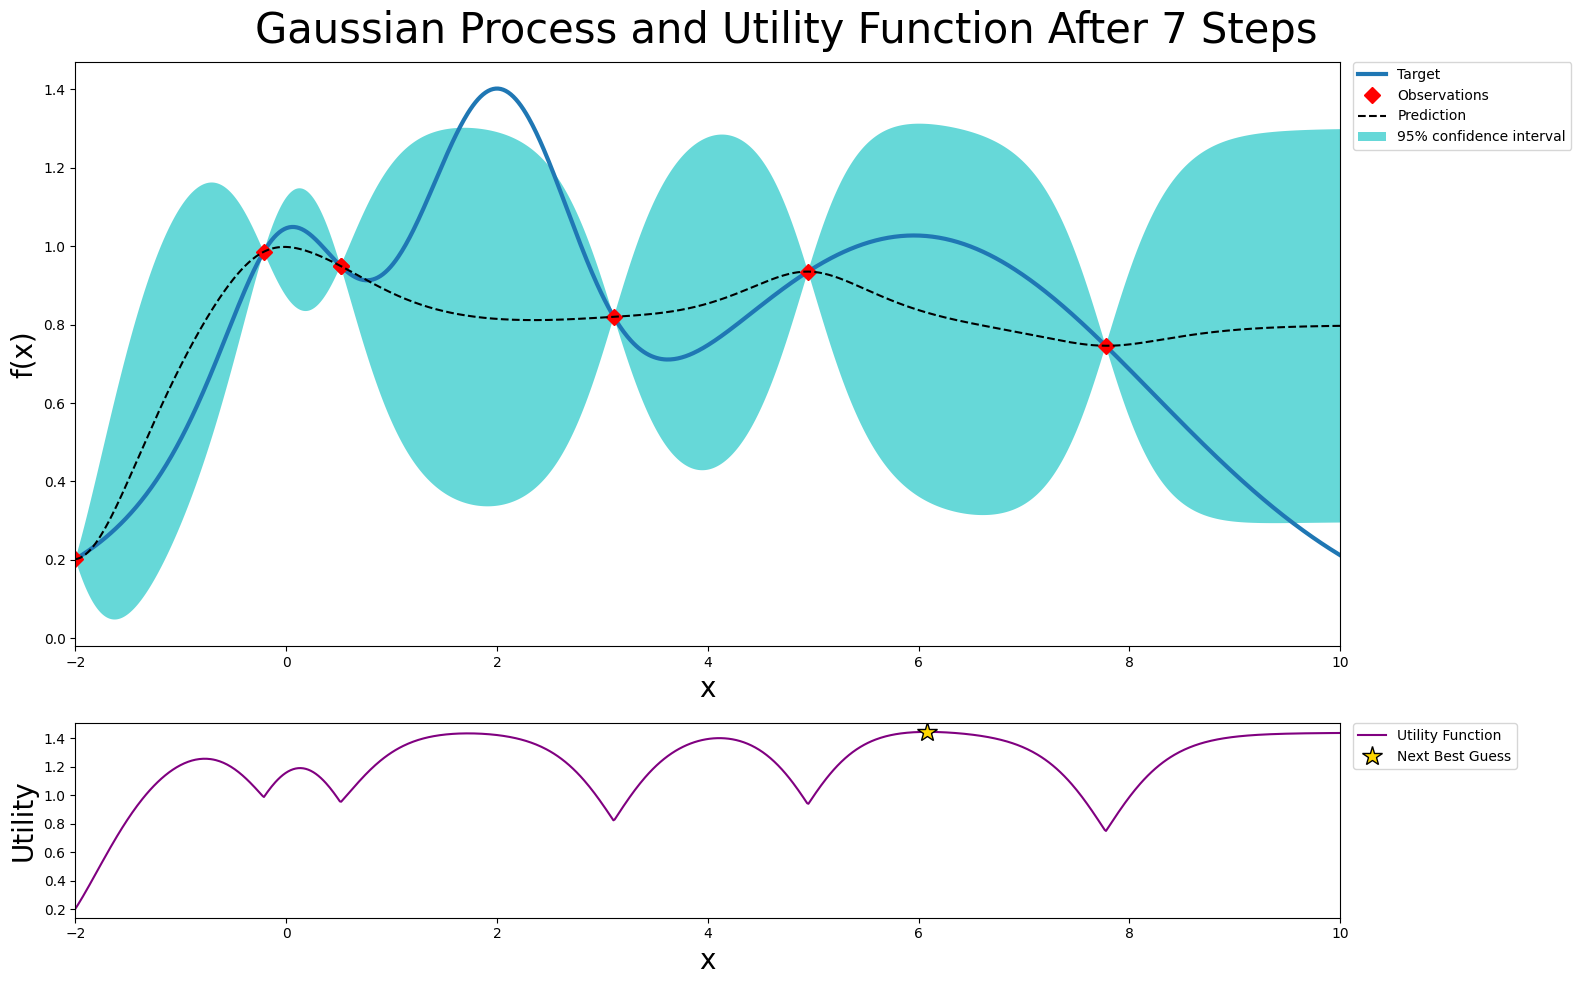

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.8354143 | -0.471662 |
| 6         | 0.9451995 | 0.9845149 |
| 7         | 0.2117975 | 10.0      |

UCB with kappa=5.0 Results:


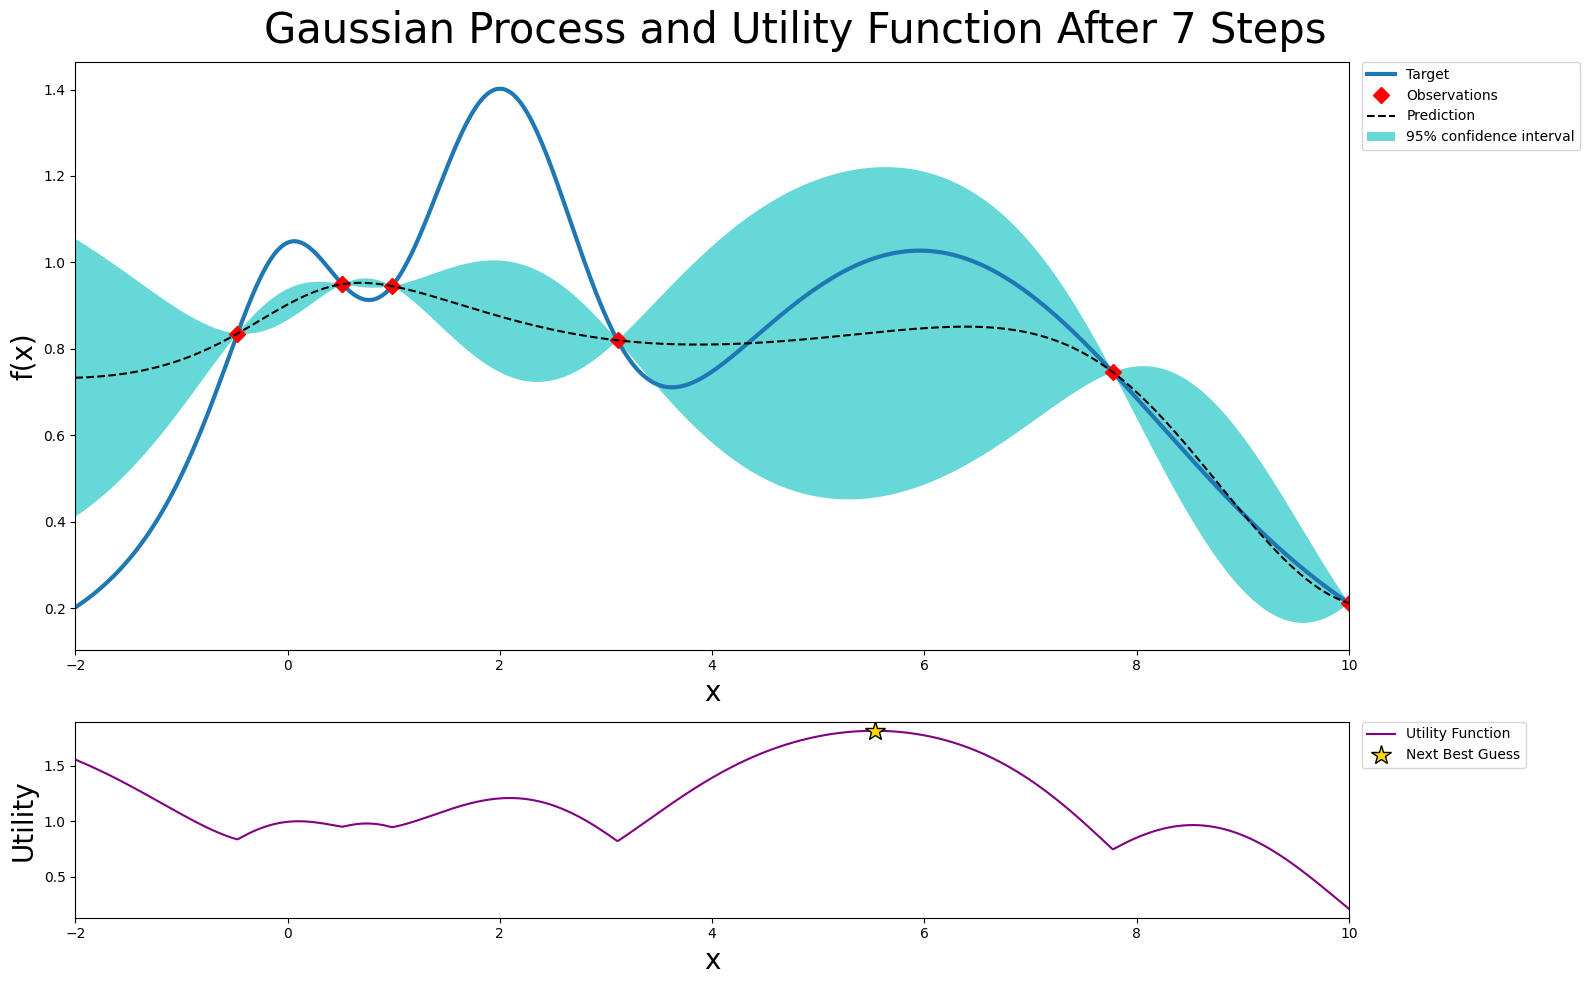

In [7]:
kappa_values = [0.1, 2.5, 5.0]

for kappa in kappa_values:
    ucb = acquisition.UpperConfidenceBound(kappa=kappa)
    optimizer_ucb = BayesianOptimization(
        f=target_function,
        pbounds={"x": (-2, 10)},
        acquisition_function=ucb,
        random_state=27,
    )

    optimizer_ucb.maximize(init_points=2, n_iter=5)
    print(f"\nUCB with kappa={kappa} Results:")
    plot_gp(optimizer_ucb, x, y)

<div class="alert alert-block alert-info">
<b>Comment:</b> Higher kappa prioritizes reducing uncertainty (more explorative), while lower rewards existing decent known points (more exploative).
</div>

Exercise 2: Chaotic Acquisition Function
-----------------------------------------
**Goal**: Implement a chaotic acquisition function that exclusively prioritizes the standard deviation of predictions, disregarding the predicted mean. Compare its performance against standard acquisition functions such as UCB and PI (Probability of Improvement).

In [8]:
class ChaoticAcquisition(acquisition.AcquisitionFunction):

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return std

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.4795761 | -1.056368 |
| 5         | 0.5994353 | 8.3148223 |
| 6         | 0.9551109 | 1.0156908 |
| 7         | 0.9990032 | 5.4116415 |

Chaotic Acquisition Results:


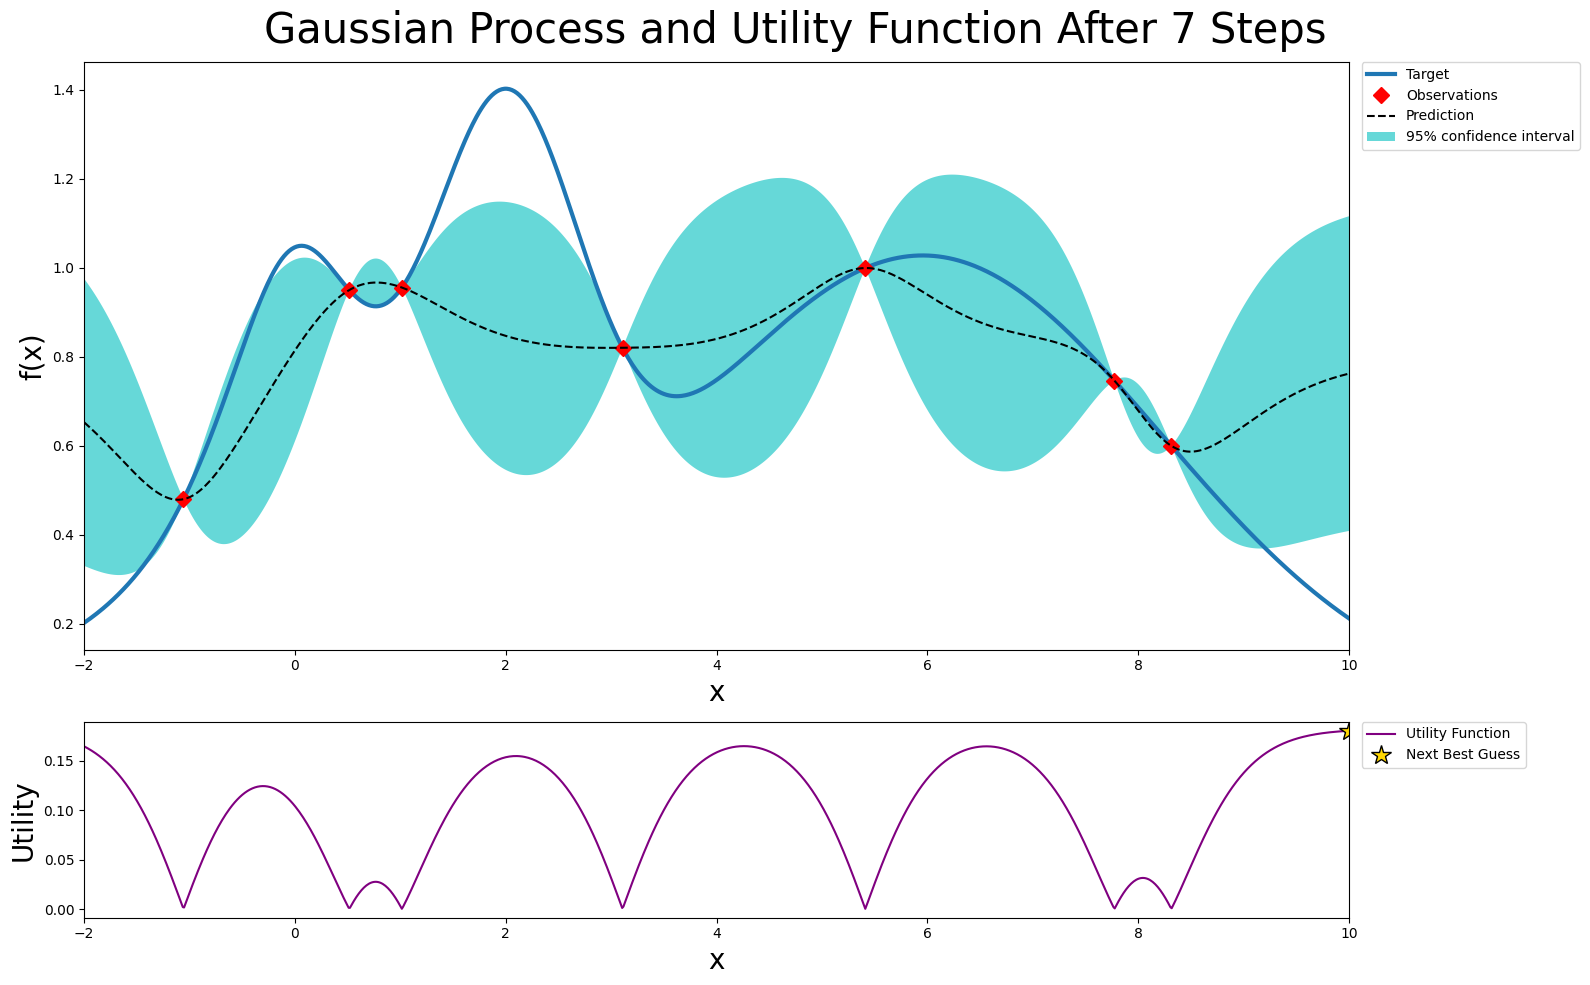

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856630 | -0.211813 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351170 | 4.9507496 |

UCB Results:


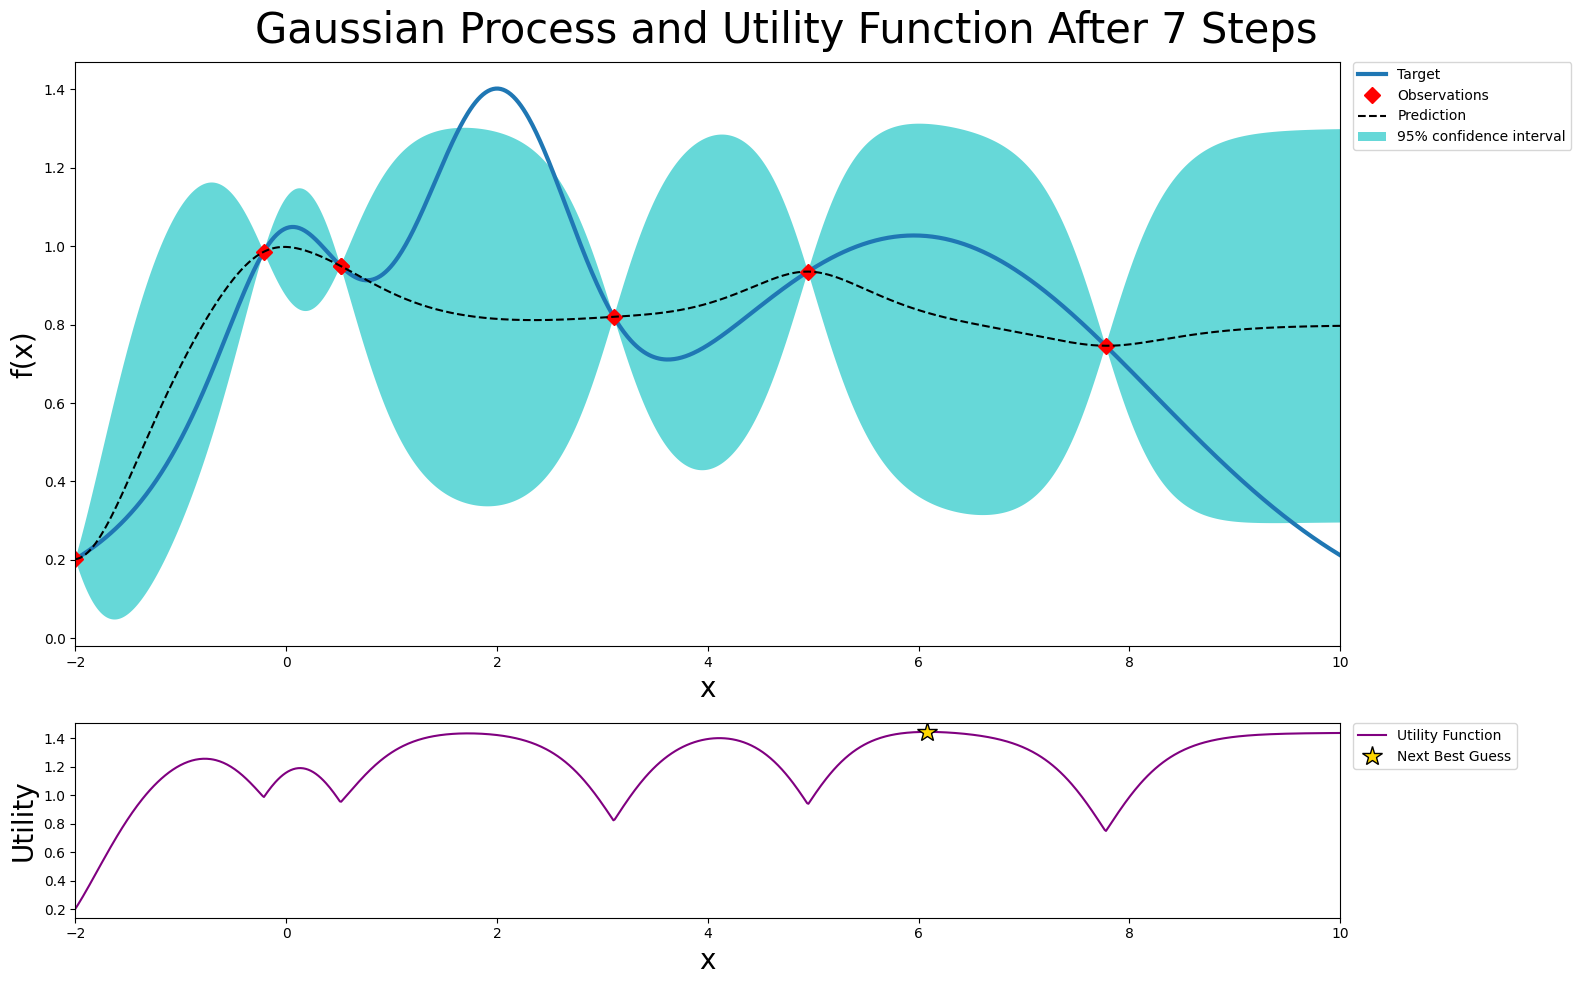

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495500 | 0.5165817 |
| 5         | 0.9526277 | 0.5049405 |
| 6         | 0.9553089 | 0.4950240 |
| 7         | 0.9594185 | 0.4801647 |

PI Results:


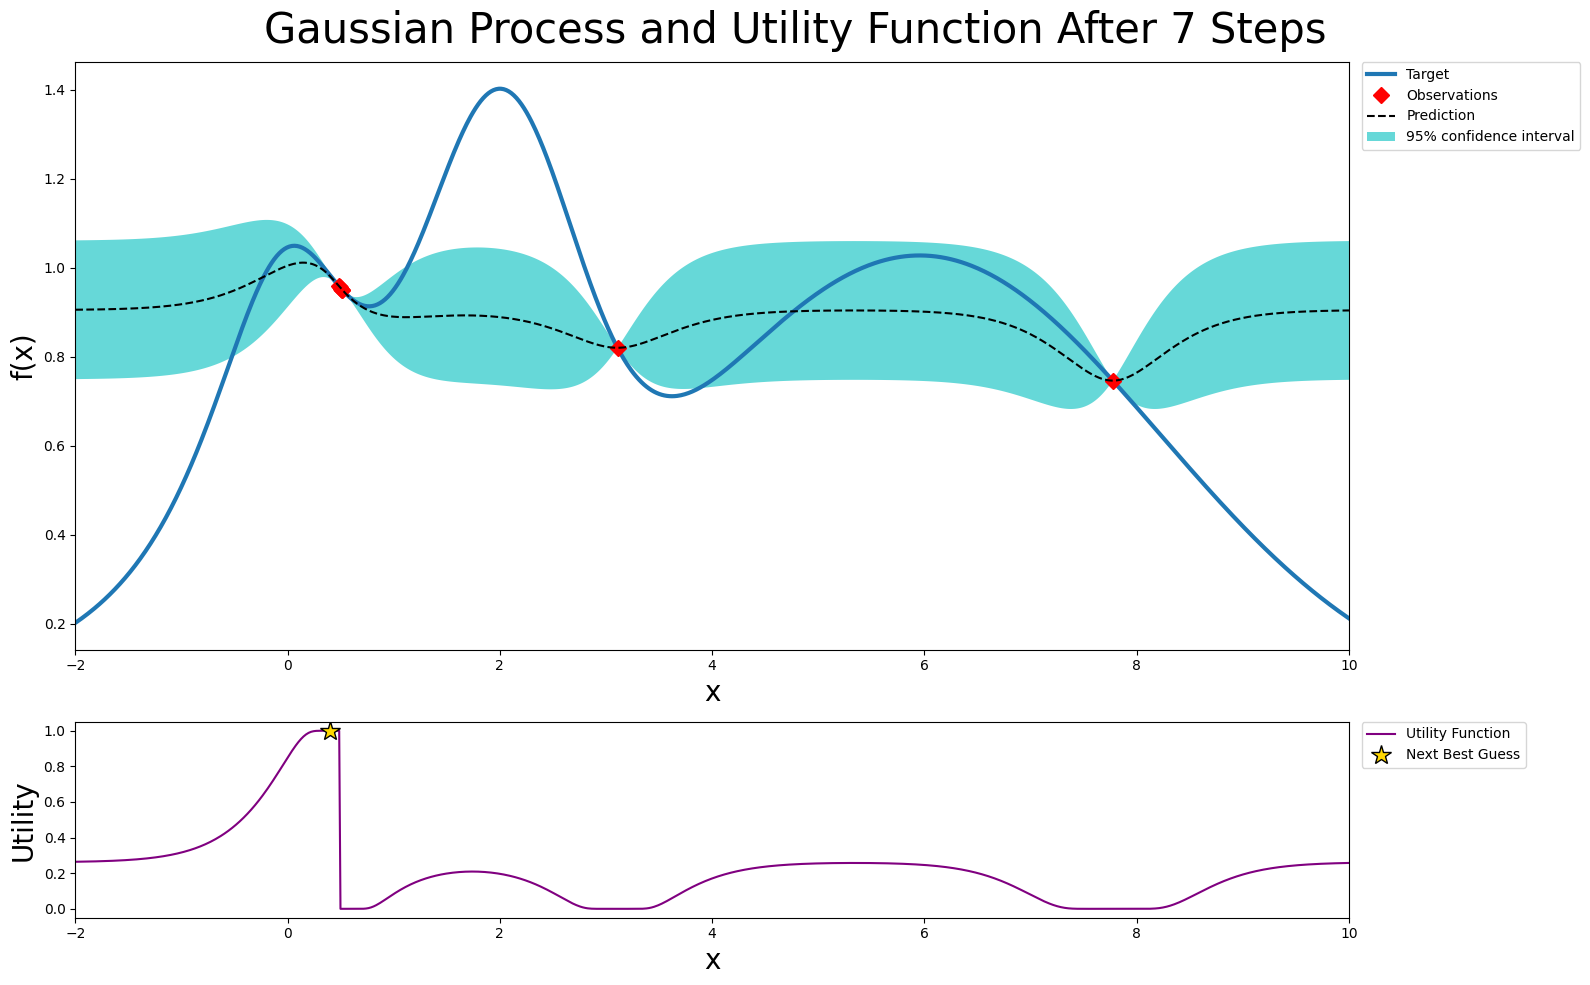


Summary of results:
Chaotic best value: 0.9990 at x = 5.4116
UCB best value: 0.9857 at x = -0.2118
PI best value: 0.9594 at x = 0.4802


In [9]:
# Chaotic acquisition
chaotic = ChaoticAcquisition()
optimizer_chaotic = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=chaotic,
    random_state=27,
)

optimizer_chaotic.maximize(init_points=2, n_iter=5)
print("\nChaotic Acquisition Results:")
plot_gp(optimizer_chaotic, x, y)

# UCB
ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Results:")
plot_gp(optimizer_ucb, x, y)

# PI
pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nPI Results:")
plot_gp(optimizer_pi, x, y)

print("\nSummary of results:")
print(
    f"Chaotic best value: {optimizer_chaotic.max['target']:.4f} at x = {optimizer_chaotic.max['params']['x']:.4f}"
)
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)

<div class="alert alert-block alert-info">
<b>Comment:</b> In this case, the extremely explorative chaotic function performed quite well, but in general, I think it's too risky to use since it suggests sampling without caring about the actual values of the function at the known points.
</div>

Exercise 3: Expected Improvement
--------------------------------

**Goal:** Implement the Expected Improvement (EI) acquisition function by extending the `AcquisitionFunction` base class provided by the `BayesOpt` library.

Expected Improvement (EI) is a popular choice for the acquisition function. Let's understand its derivation:

1.  **Current Best:** After $n$ evaluations, the best function value observed *so far* is $f^* = \max_{m=1..n} f(x_m)$.

2.  **Potential Improvement:** If we evaluate a new point $x$, the *actual* improvement over the current best $f^*$ is $\max(f(x) - f^*, 0)$, sometimes written as $[f(x) - f^*]^+$.

3.  **The Challenge:** We want to choose $x$ to maximize this improvement, but $f(x)$ is unknown *before* evaluation.

4.  **The Solution: Expected Improvement:** Our probabilistic model gives a posterior distribution for $f(x)$ at any point $x$. Given the data, this is typically a Gaussian distribution: $f(x) \sim \mathcal{N}(\mu_n(x), \sigma_n^2(x))$. EI maximizes the *expected* value of the improvement, where the expectation is taken over this posterior distribution:

    $EI_n(x) = E_n[ \max(f(x) - f^*, 0) ]$

    This value represents, on average, how much we expect to improve upon $f^*$ by evaluating at $x$. The next point chosen is the one that maximizes $EI_n(x)$.

### Mathematical Formulation

The expected improvement integral can be computed analytically. The standard closed-form expression is:

$$
EI(x) =
\begin{cases}
(\mu(x) - f^*) \Phi(Z) + \sigma(x) \varphi(Z) & \text{if } \sigma(x) > 0 \\
0 & \text{if } \sigma(x) = 0
\end{cases}
$$

Where:

* $\mu(x)$: The posterior mean of $f(x)$ at point $x$.
* $\sigma(x)$: The posterior standard deviation of $f(x)$ at point $x$.
* $f^*$: The best function value observed so far (a single scalar value).
* $Z = \frac{\mu(x) - f^*}{\sigma(x)}$
* $\Phi(Z)$: The Cumulative Distribution Function (CDF) of the standard normal distribution $\mathcal{N}(0, 1)$.
* $\varphi(Z)$: The Probability Density Function (PDF) of the standard normal distribution $\mathcal{N}(0, 1)$.

### Implementation Task

Create a class `ExpectedImprovement` inheriting from `acquisition.AcquisitionFunction` and implement the core calculation in the `base_acq` method. The signature of `base_acq` method looks like this:
```python
def base_acq(self, mean: NDArray[Float], std: NDArray[Float]) -> NDArray[Float]:
```

Compare its performance against other acquisition functions.

Hint: Analyse the source code of [ProbabilityOfImprovement](https://github.com/bayesian-optimization/BayesianOptimization/blob/d5126dc2462fddf50047519d6ef6125f271e0650/bayes_opt/acquisition.py#L583) class to better understand how to use/update $f^*$ (`self.y_max`).

In [13]:
from scipy.stats import norm

class ExpectedImprovement(acquisition.AcquisitionFunction):

    def __init__(self, xi=0.01, random_state=None):
        super().__init__(random_state)
        self.xi = xi
        self.y_max = None

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        z = (mean - self.y_max - self.xi) / std
        ei = (mean - self.y_max - self.xi) * norm.cdf(z) + std * norm.pdf(z)
        
        return ei

    def suggest(
        self,
        gp,
        target_space,
        n_random=10_000,
        n_smart=10,
        fit_gp=True,
        random_state=None,
    ):
        y_max = target_space._target_max()
        self.y_max = y_max
        x_max = super().suggest(
            gp=gp,
            target_space=target_space,
            n_random=n_random,
            n_smart=n_smart,
            fit_gp=fit_gp,
            random_state=random_state,
        )
        return x_max

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495496 | 0.5165830 |
| 5         | 1.0170648 | 0.2802822 |
| 6         | 1.0486129 | 0.0424229 |
| 7         | 0.7648218 | -0.576904 |

Expected Improvement Results:


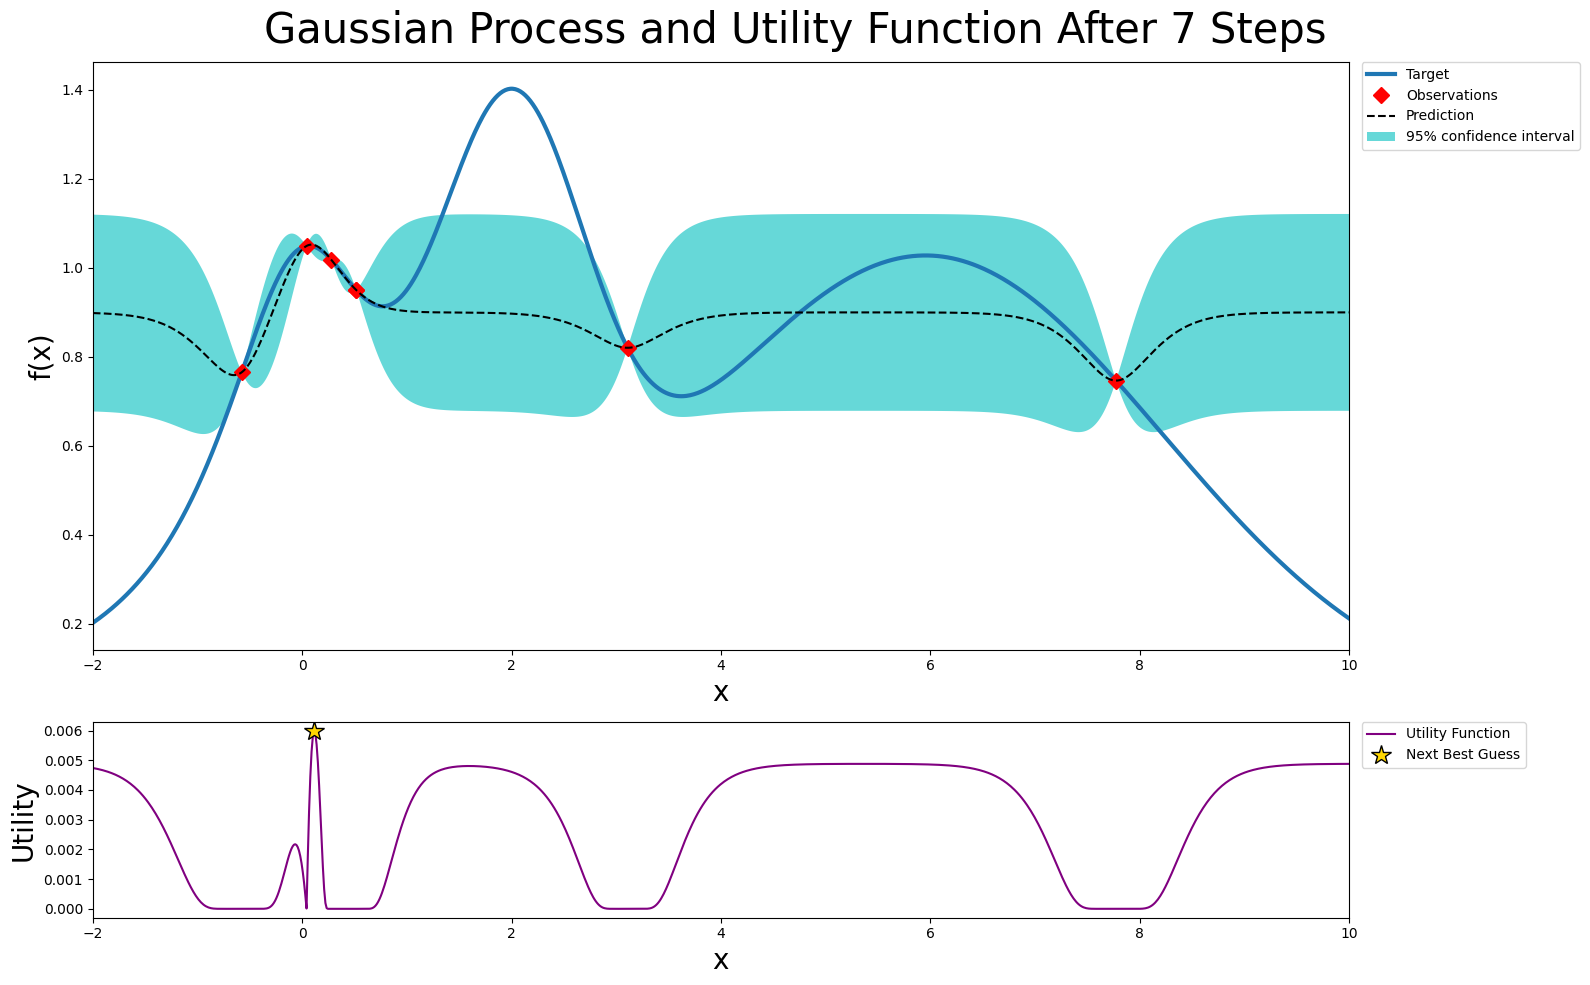

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856630 | -0.211813 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351170 | 4.9507496 |

UCB Results:


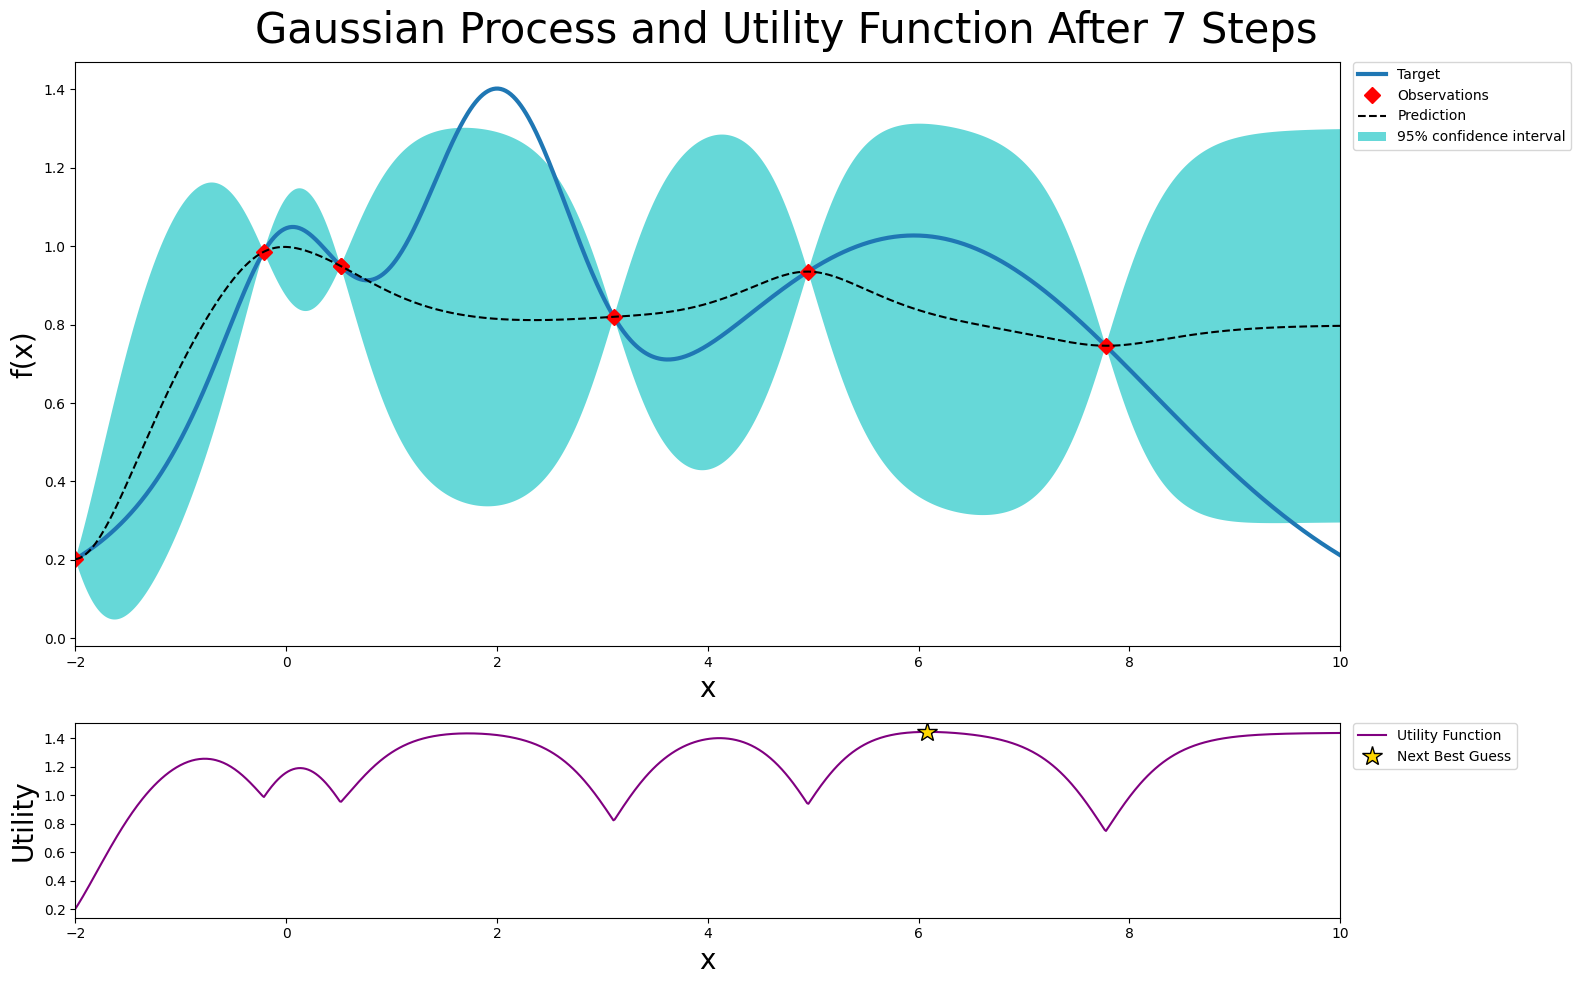

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495500 | 0.5165817 |
| 5         | 0.9526277 | 0.5049405 |
| 6         | 0.9553089 | 0.4950240 |
| 7         | 0.9594185 | 0.4801647 |

PI Results:


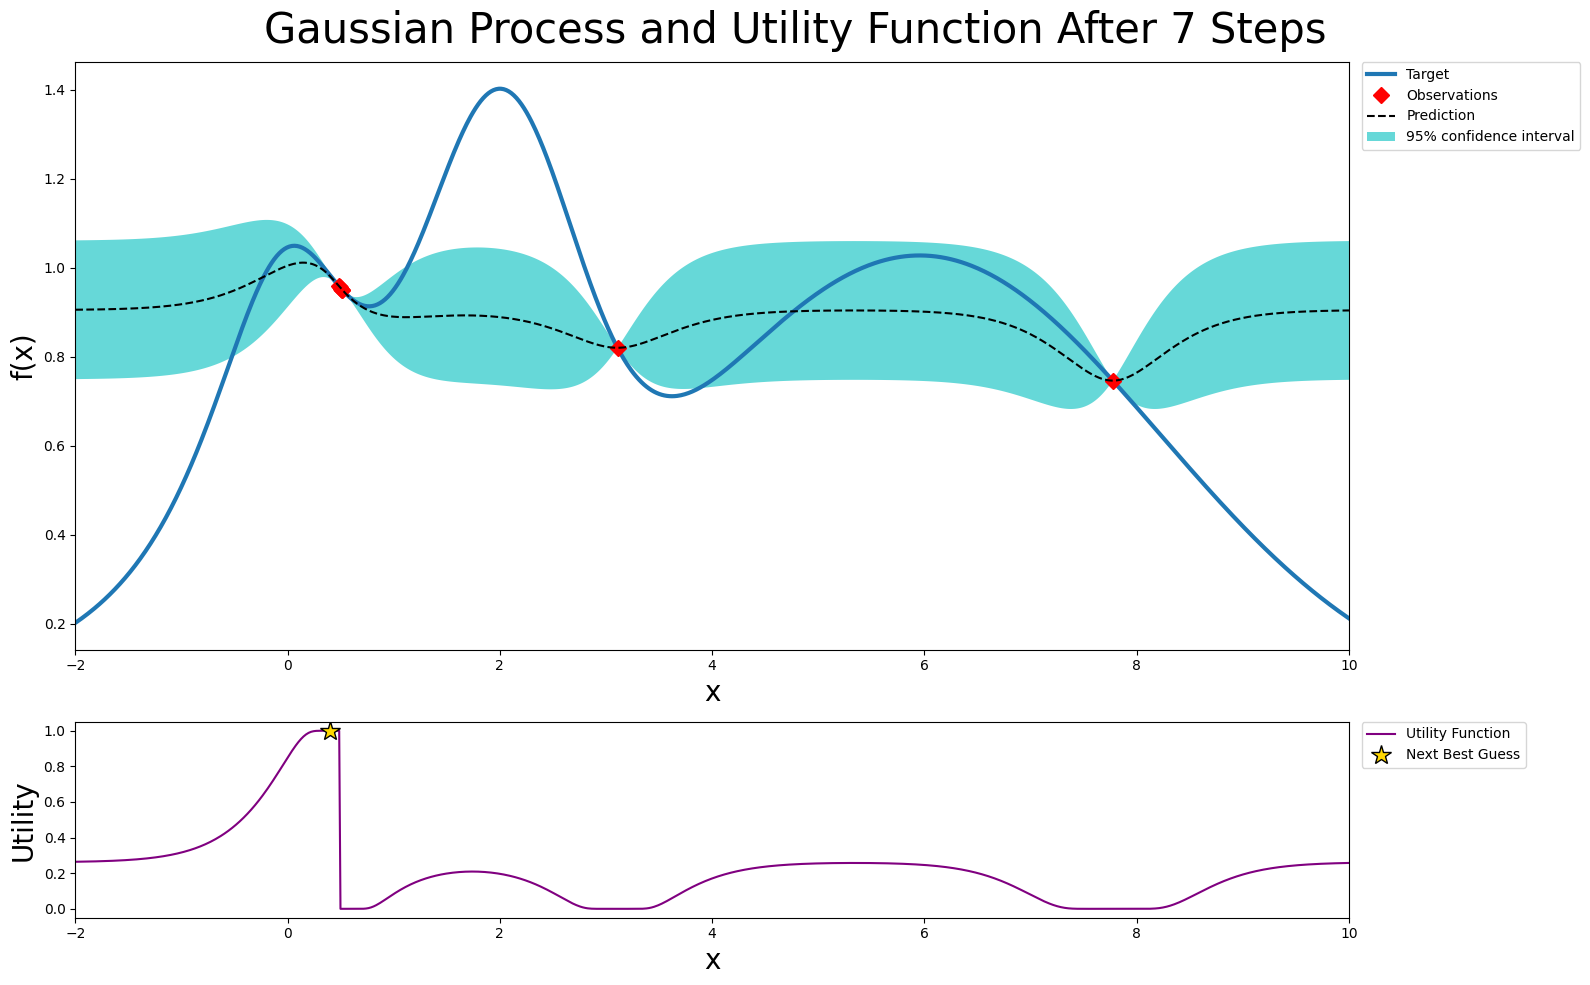

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495499 | 0.5165820 |
| 5         | 0.9495499 | 0.5165820 |
| 6         | 0.9495499 | 0.5165820 |
| 7         | 0.9495499 | 0.5165820 |

Greedy Results:


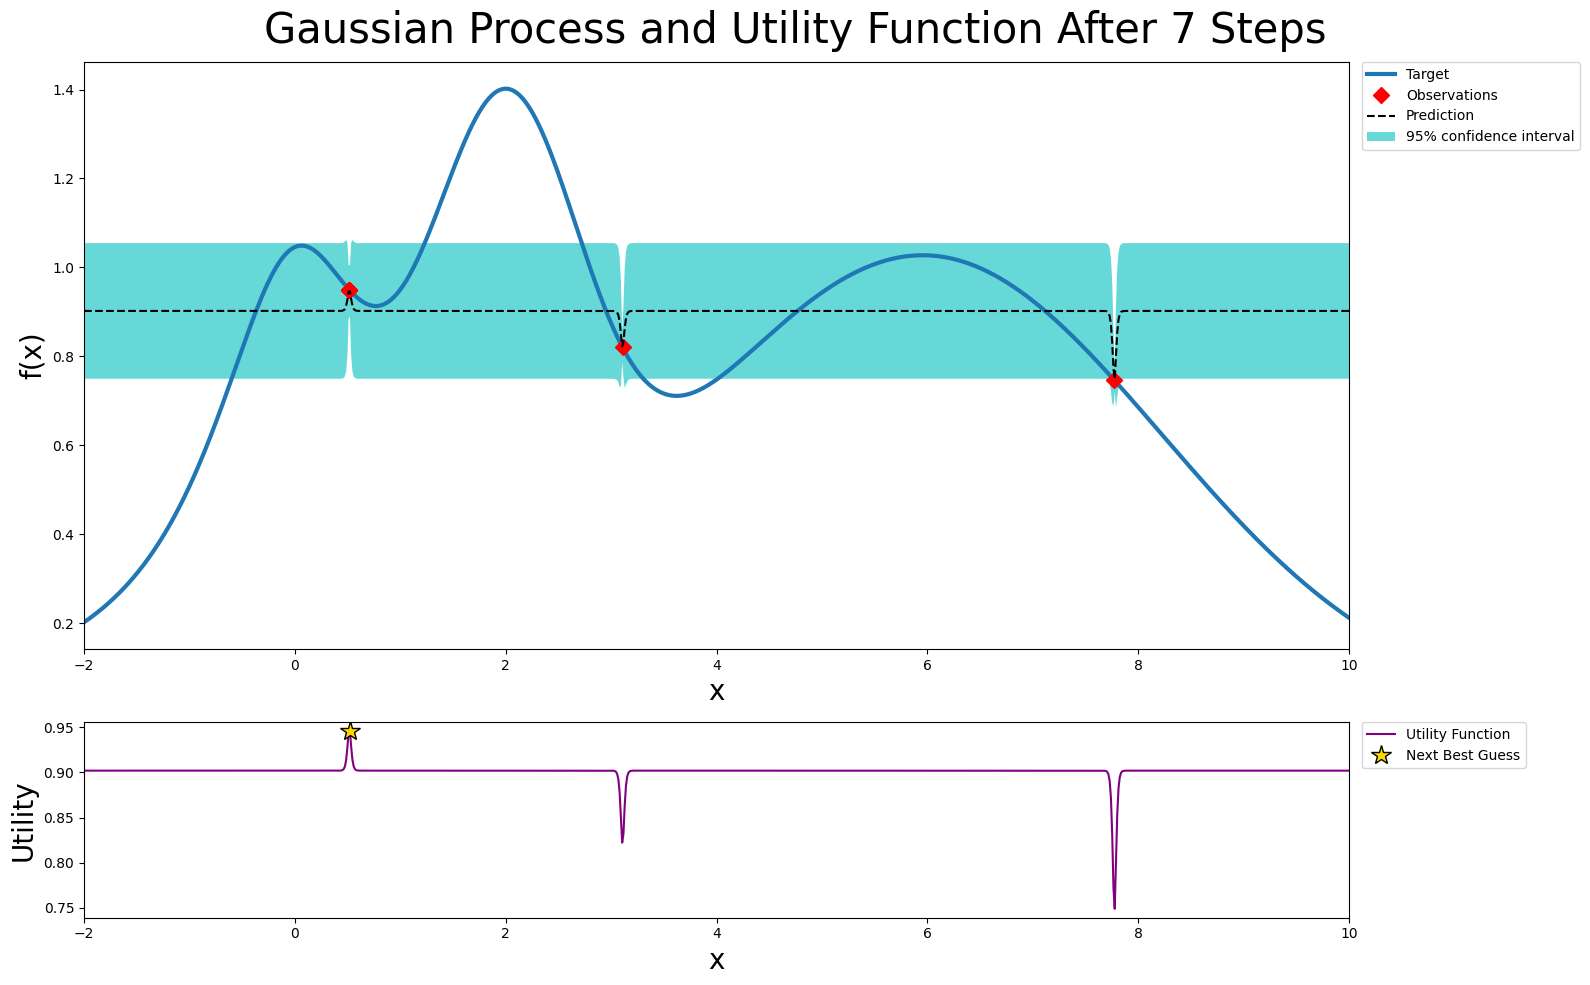


Summary of results:
EI best value: 1.0486 at x = 0.0424
UCB best value: 0.9857 at x = -0.2118
PI best value: 0.9594 at x = 0.4802
Greedy best value: 0.9495 at x = 0.5166


In [14]:
# EI
ei = ExpectedImprovement(xi=1e-4)
optimizer_ei = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ei,
    random_state=27,
)

optimizer_ei.maximize(init_points=2, n_iter=5)
print("\nExpected Improvement Results:")
plot_gp(optimizer_ei, x, y)

# UCB
ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Results:")
plot_gp(optimizer_ucb, x, y)

# PI
pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nPI Results:")
plot_gp(optimizer_pi, x, y)

# Greedy
greedy = GreedyAcquisition()
optimizer_greedy = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=greedy,
    random_state=27,
)

optimizer_greedy.maximize(init_points=2, n_iter=5)
print("\nGreedy Results:")
plot_gp(optimizer_greedy, x, y)

# Summary
print("\nSummary of results:")
print(
    f"EI best value: {optimizer_ei.max['target']:.4f} at x = {optimizer_ei.max['params']['x']:.4f}"
)
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)
print(
    f"Greedy best value: {optimizer_greedy.max['target']:.4f} at x = {optimizer_greedy.max['params']['x']:.4f}"
)

<div class="alert alert-block alert-info">
<b>Comment:</b> Expected improvement did the best in this case. I think that I find this method the most convincing.
</div>

Exercise 4: Theoretical Questions
--------------------------------
1. Why is Bayesian Optimization particularly useful for expensive-to-evaluate functions?
2. Compare and contrast the different acquisition functions discussed in this tutorial.
3. What are the limitations of Bayesian Optimization?

<div class="alert alert-block alert-info">
<b>Comment:</b> Bayesian Optimization is highly efficient because it aims to find the global optimum with the minimum number of function evaluations. Instead of sampling blindly, BO uses a surrogate model to build a probabilistic representation of the objective function. This provides both a predicted value and a measure of uncertainty across the domain, allowing the algorithm to make informed decisions about where to sample next.

Differenet acquistion functions provides different approach in sampling. A greedy approach is purely exploitative, sampling only where the model predicts high values, while a chaotic approach ignores values and samples only where uncertainty is highest. UCB rovides a transparent balance between the two by using a $\kappa$ parameter to weigh the predicted mean against the standard deviation. PI focuses on picking the points where with highest probability we will find even slightly higher value when IT focuses on finding the one that will improve our current best the most.

The limitations are, of course, that we will never know the whole function for sure, and sometimes we will still need many samples to get a reasonable prediction. Moreover, it might be hard to choose a suitable acquisition function when we know nothing about the true function.
</div>